# 🚕 Análisis de Datos — Trabajo Práctico Integrador

**CEIA-FIUBA · Análisis de Datos · 2B 2026 · Grupo N.º 13**

**Integrantes:** Fioranelli, Rocío · Lerner, Federico · Makk, Azul · Moguilner Reh, Nicolás · Varela, Gustavo

Este notebook cubre el flujo completo del trabajo práctico:

1. Exploración y comprensión de los datos
2. Técnicas de visualización
3. Planteo del problema de ML supervisado
4. Preprocesamiento, limpieza y split train/test
5. Feature Engineering
6. Reducción de dimensionalidad (PCA)
7. Resumen del dataset listo para modelado
8. Conclusiones

## Diccionario de datos — NYC TLC Trip Records

Fuente: [http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml](http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml)

| Field Name | Description |
|---|---|
| `VendorID` | A code indicating the TPEP provider that provided the record.<br>1 = Creative Mobile Technologies, LLC<br>2 = Curb Mobility, LLC<br>6 = Myle Technologies Inc<br>7 = Helix |
| `tpep_pickup_datetime` | The date and time when the meter was engaged. |
| `tpep_dropoff_datetime` | The date and time when the meter was disengaged. |
| `passenger_count` | The number of passengers in the vehicle. |
| `trip_distance` | The elapsed trip distance in miles reported by the taximeter. |
| `RatecodeID` | The final rate code in effect at the end of the trip.<br>1 = Standard rate<br>2 = JFK<br>3 = Newark<br>4 = Nassau or Westchester<br>5 = Negotiated fare<br>6 = Group ride<br>99 = Null/unknown |
| `store_and_fwd_flag` | This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka "store and forward," because the vehicle did not have a connection to the server.<br>Y = store and forward trip<br>N = not a store and forward trip |
| `PULocationID` | TLC Taxi Zone in which the taximeter was engaged. |
| `DOLocationID` | TLC Taxi Zone in which the taximeter was disengaged. |
| `payment_type` | A numeric code signifying how the passenger paid for the trip.<br>0 = Flex Fare trip<br>1 = Credit card<br>2 = Cash<br>3 = No charge<br>4 = Dispute<br>5 = Unknown<br>6 = Voided trip |
| `fare_amount` | The time-and-distance fare calculated by the meter. For additional information on the following columns, see https://www.nyc.gov/site/tlc/passengers/taxi-fare.page |
| `extra` | Miscellaneous extras and surcharges. |
| `mta_tax` | Tax that is automatically triggered based on the metered rate in use. |
| `tip_amount` | Tip amount. This field is automatically populated for credit card tips. Cash tips are not included. |
| `tolls_amount` | Total amount of all tolls paid in trip. |
| `improvement_surcharge` | Improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
| `total_amount` | Total amount charged to passengers. Does not include cash tips. |
| `congestion_surcharge` | Total amount collected in trip for NYS congestion surcharge. |
| `airport_fee` | For pick up only at LaGuardia and John F. Kennedy Airports. |
| `cbd_congestion_fee` | Per-trip charge for MTA's Congestion Relief Zone starting Jan 5, 2025. |


## Exploración preliminar

Primeras consultas al dataset en crudo.


In [1]:
from pathlib import Path
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [2]:
# Mostramos el dataset y sus columnas con los primeros 5 registros
DATA_PATH = Path("dataset") / "yellow_tripdata_2026-03.parquet"
df = pd.read_parquet(DATA_PATH)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-03-01 00:02:26,2026-03-01 00:13:45,1.0,2.58,1.0,N,48,151,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2,2026-03-01 00:19:33,2026-03-01 00:28:21,1.0,1.50,1.0,N,238,166,1,10.0,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.0,0.00
2,2,2026-03-01 00:07:20,2026-03-01 00:15:12,2.0,0.88,1.0,N,90,249,1,8.6,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
3,2,2026-03-01 00:16:11,2026-03-01 00:28:20,1.0,1.76,1.0,N,249,137,1,12.1,1.0,0.5,3.57,0.0,1.0,21.42,2.5,0.0,0.75
4,2,2026-03-01 00:20:47,2026-03-01 00:30:44,2.0,1.57,1.0,N,100,142,1,11.4,1.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75


In [3]:
# Mostramos la cantidad de filas y columnas, y el tipo de dato de cada columna
print("Filas, columnas:", df.shape)
df.dtypes

Filas, columnas: (3952451, 20)


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [4]:
# Mostramos la memoria que ocupa el dataset
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3952451 entries, 0 to 3952450
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [5]:
# Mostramos la estadistica descriptiva del dataset
df.describe().round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3952451.00,3952451,3952451,3006703.00,3952451.00,3006703.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3006703.00,3006703.00,3952451.00
mean,1.88,2026-03-16 09:09:15.947559,2026-03-16 09:26:33.369682,1.23,5.98,5.64,161.51,160.86,0.88,21.33,1.12,0.49,2.86,0.53,0.95,30.10,2.19,0.16,0.53
min,1.00,2008-12-31 23:03:20,2009-01-01 00:07:36,0.00,0.00,1.00,1.00,1.00,0.00,-990.00,-7.50,-0.50,-75.75,-111.79,-1.00,-1022.46,-2.50,-2.00,-0.75
25%,2.00,2026-03-08 17:38:26,2026-03-08 17:55:32,1.00,1.01,1.00,114.00,107.00,1.00,10.00,0.00,0.50,0.00,0.00,1.00,17.22,2.50,0.00,0.00
50%,2.00,2026-03-16 08:13:05,2026-03-16 08:32:14,1.00,1.82,1.00,161.00,162.00,1.00,15.60,0.00,0.50,2.11,0.00,1.00,23.40,2.50,0.00,0.75
75%,2.00,2026-03-23 17:55:51.500000,2026-03-23 18:13:19,1.00,3.71,1.00,233.00,234.00,1.00,26.80,2.50,0.50,3.95,0.00,1.00,34.90,2.50,0.00,0.75
max,7.00,2026-04-01 00:06:25,2026-04-02 16:03:47,8.00,288381.68,99.00,265.00,265.00,4.00,1843.30,17.46,4.75,397.00,1400.00,1.00,1850.55,2.50,27.00,0.75
std,0.72,NaN,NaN,0.63,581.05,20.59,66.57,70.71,0.63,18.69,1.75,0.09,3.91,2.29,0.24,22.41,0.87,0.55,0.35


In [6]:
# Mostramos la cantidad de nulos de aquellas columnas que tienen nulos
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

Airport_fee             945748
passenger_count         945748
congestion_surcharge    945748
RatecodeID              945748
store_and_fwd_flag      945748
dtype: int64

In [7]:
print('Cantidad máxima de pasajeros transportados en un viaje:', (df['passenger_count']).max())

print('Viajes con +2 pasajeros', (df['passenger_count'] > 2).sum())

print('Viajes con +3 pasajeros', (df['passenger_count'] > 3).sum())

print('Viajes con +4 pasajeros', (df['passenger_count'] > 4).sum())

print('Viajes con +5 pasajeros', (df['passenger_count'] > 5).sum())

print('Viajes con +5 pasajeros', (df['passenger_count'] > 7).sum())

# Descripción de la columna passenger_count
df['passenger_count'].describe()

Cantidad máxima de pasajeros transportados en un viaje: 8.0
Viajes con +2 pasajeros 137659
Viajes con +3 pasajeros 61761
Viajes con +4 pasajeros 13612
Viajes con +5 pasajeros 5130
Viajes con +5 pasajeros 3


count    3.006703e+06
mean     1.230823e+00
std      6.330375e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: passenger_count, dtype: float64

In [8]:
# Descripción de la columna payment_type
df['payment_type'].describe()

# 0: Flex Fare trip
# 1: Credit card
# 2: Cash
# 3: No charge
# 4: Dispute
# 5: Unknown
# 6: Voided trip

count    3.952451e+06
mean     8.805670e-01
std      6.317968e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

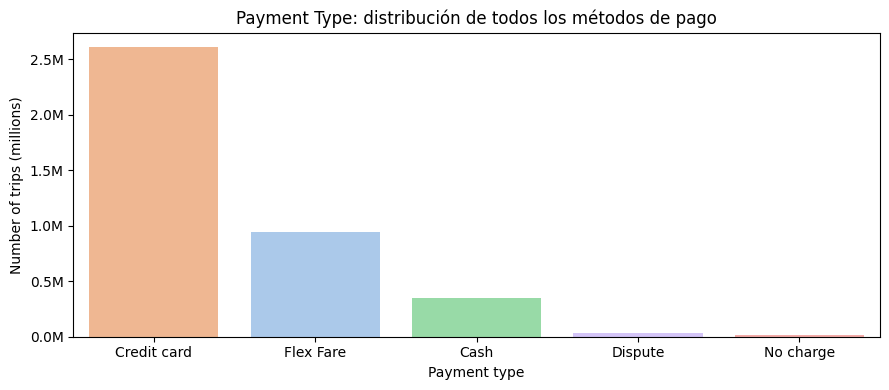

In [9]:
# Distribución de todos los métodos de pago (payment_type)
payment_labels = {
    0: 'Flex Fare',
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip',
}

# Orden por frecuencia descendente, considerando solo los códigos presentes
order = df['payment_type'].value_counts().index.tolist()

plt.figure(figsize=(9, 4))
ax = sns.countplot(
    data=df,
    x='payment_type',
    hue='payment_type',
    order=order,
    palette='pastel',
    legend=False
)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([payment_labels.get(code, str(code)) for code in order])
plt.title('Payment Type: distribución de todos los métodos de pago')
plt.xlabel('Payment type')
plt.ylabel('Number of trips (millions)')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

plt.tight_layout()
plt.show()

In [10]:
# Muestra de la columna tip_amount
df['tip_amount'].describe()

print(f"hay {(df['tip_amount'] < 0).sum()} propinas negativas. se pagó de menos, ajuste contable?")
print(f"el 50% deja entre {df['tip_amount'].quantile(0.25)} y {df['tip_amount'].quantile(0.75)} usd de propina, el promedio es de {df['tip_amount'].mean():.2f}")
print(f"la propina máxima fue de {df['tip_amount'].max():.2f} usd")

hay 40 propinas negativas. se pagó de menos, ajuste contable?
el 50% deja entre 0.0 y 3.95 usd de propina, el promedio es de 2.86
la propina máxima fue de 397.00 usd


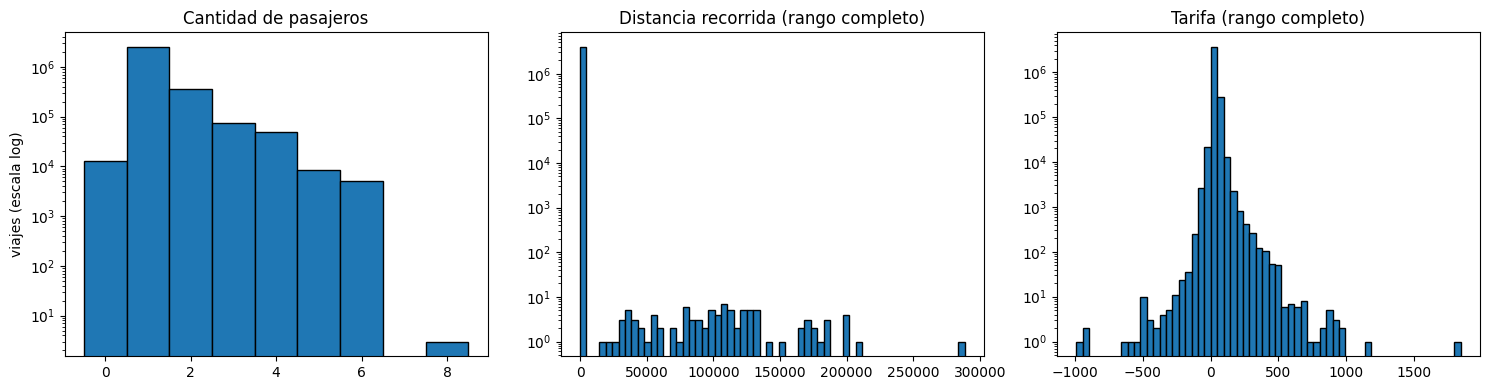

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Escala log en Y: permite ver los bins minoritarios de la cola
# (con escala lineal, los outliers extremos aplastan todo en una sola barra)
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_yscale('log'); ax[0].set_ylabel('viajes (escala log)')

ax[1].hist(df['trip_distance'], bins=60, edgecolor='black')
ax[1].set_title('Distancia recorrida (rango completo)')
ax[1].set_yscale('log')

ax[2].hist(df['fare_amount'], bins=60, edgecolor='black')
ax[2].set_title('Tarifa (rango completo)')
ax[2].set_yscale('log')

plt.tight_layout()
plt.show()
# La escala log revela los outliers: distancias de hasta ~288 mil millas y
# tarifas negativas / de ~1.800 USD que en escala lineal eran invisibles.

In [12]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

trip_distance_Q1, trip_distance_Q2, trip_distance_Q3 = cuartiles(df['trip_distance'])

print("Q1 (25%):", trip_distance_Q1, "millas")
print("Q2 (Mediana, 50%):", trip_distance_Q2, "millas")
print("Q3 (75%):", trip_distance_Q3, "millas")

trip_distance_IQR = trip_distance_Q3 - trip_distance_Q1
print("Rango intercuartil (IQR):", trip_distance_IQR, "millas")

Q1 (25%): 1.01 millas
Q2 (Mediana, 50%): 1.82 millas
Q3 (75%): 3.71 millas
Rango intercuartil (IQR): 2.7 millas


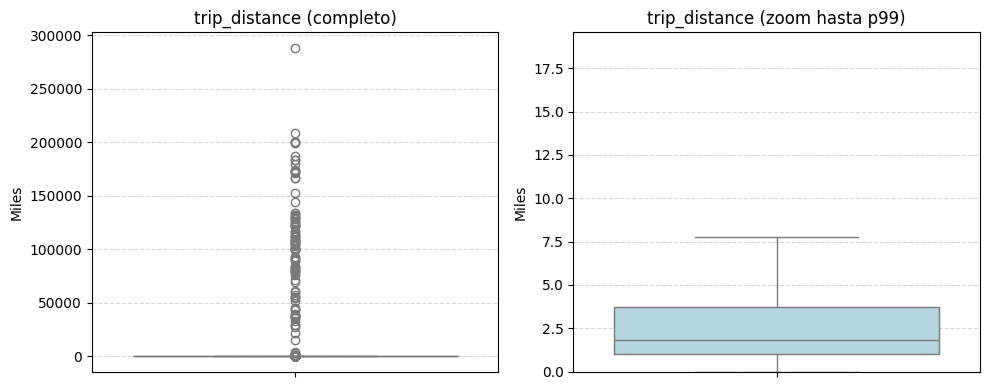

p99 de trip_distance: 19.58


In [13]:
trip_distance = df['trip_distance'].dropna()
trip_distance_pos = trip_distance[trip_distance >= 0]

p99 = trip_distance_pos.quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Boxplot completo (sin ocultar outliers)
sns.boxplot(y=trip_distance_pos, color='lightblue', ax=ax[0])
ax[0].set_title('trip_distance (completo)')
ax[0].set_ylabel('Miles')
ax[0].grid(axis='y', ls='--', alpha=0.5)

# Boxplot con zoom hasta percentil 99
sns.boxplot(y=trip_distance_pos, color='lightblue', showfliers=False, ax=ax[1])
ax[1].set_ylim(0, p99)
ax[1].set_title('trip_distance (zoom hasta p99)')
ax[1].set_ylabel('Miles')
ax[1].grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'p99 de trip_distance: {p99:.2f}')

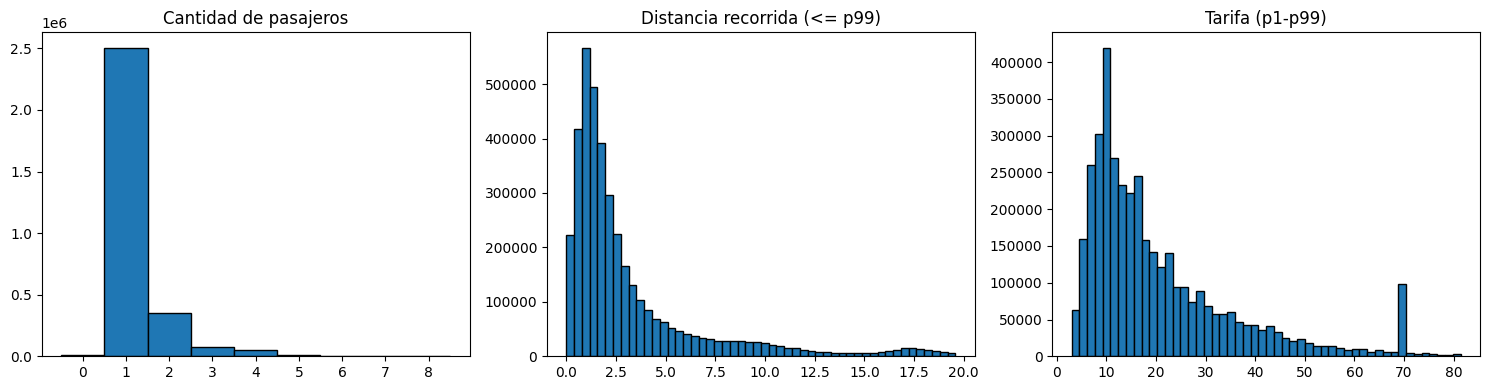

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# passenger_count como bins enteros
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_xticks(range(0, 9))

# trip_distance sin extremos (p99)
d = df['trip_distance'].dropna()
d = d[(d >= 0) & (d <= d.quantile(0.99))]
ax[1].hist(d, bins=50, edgecolor='black')
ax[1].set_title('Distancia recorrida (<= p99)')

# fare_amount sin extremos (p1-p99)
f = df['fare_amount'].dropna()
f = f[(f >= f.quantile(0.01)) & (f <= f.quantile(0.99))]
ax[2].hist(f, bins=50, edgecolor='black')
ax[2].set_title('Tarifa (p1-p99)')

plt.tight_layout()
plt.show()

## Resumen de hallazgos

| # | Hallazgo | Implicancia para el trabajo |
|---|----------|------------------------------|
| 1 | 3.952.451 viajes × 20 variables (marzo 2026), ~750 MB en RAM | Volumen sobrado para entrenar; exige técnicas eficientes |
| 2 | 23,93 % de faltantes en 5 columnas, 100 % coincidentes con viajes Flex Fare (`payment_type=0`) | Faltante MAR/estructural → se excluye Flex Fare al restringir el universo a tarjeta |
| 3 | Errores físicos: 1,24 % de duraciones ≤ 0, distancias de hasta 288 mil millas, ~21 mil importes negativos, fechas de 2008 | Limpiamos lo imposible; los viajes raros pero válidos se acotan (winsorización) |
| 4 | Pearson distancia~duración ≈ 0 en crudo vs Spearman 0,79 / Kendall 0,63 | Los outliers distorsionan medidas clásicas → estadística robusta en todo el flujo |
| 5 | `tip_amount` solo se registra con tarjeta; en efectivo es 0 siempre (MNAR) | Universo restringido a tarjeta (2.608.830 viajes, 66 %) |
| 6 | Con tarjeta, el 90,2 % deja propina; mediana 3,20 USD (cola hasta 397 USD en crudo) | Target = regresión de `tip_amount` (USD); extremos tratados como outliers |


In [15]:
# Configuración estética unificada para las visualizaciones de esta parte
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
                     'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Exploración y comprensión de los datos

### 1.1 Estructura general del dataset


In [16]:
# Resumen estructural: nº de observaciones, nº de variables y tipos de datos
n_obs, n_vars = df.shape
print(f'Observaciones (viajes): {n_obs:,}')
print(f'Variables (columnas):  {n_vars}')
print(f'Memoria en RAM:        {df.memory_usage(deep=True).sum()/1e6:,.1f} MB')

tipos = (df.dtypes.astype(str)
           .replace({'int32':'entero','int64':'entero','float64':'flotante',
                     'object':'texto/categórica','datetime64[us]':'fecha-hora'}))
resumen_tipos = tipos.value_counts().rename('cantidad').to_frame()
resumen_tipos

Observaciones (viajes): 3,952,451
Variables (columnas):  20
Memoria en RAM:        726.4 MB


,cantidad
flotante,13
entero,4
fecha-hora,2
texto/categórica,1


In [17]:
# Clasificación semántica de las variables (más útil que el dtype crudo)
variables = {
    'numéricas continuas': ['trip_distance','fare_amount','extra','mta_tax','tip_amount',
                            'tolls_amount','improvement_surcharge','total_amount',
                            'congestion_surcharge','Airport_fee','cbd_congestion_fee'],
    'numéricas discretas': ['passenger_count'],
    'categóricas nominales': ['VendorID','RatecodeID','store_and_fwd_flag',
                              'payment_type','PULocationID','DOLocationID'],
    'temporales': ['tpep_pickup_datetime','tpep_dropoff_datetime'],
}
for tipo, cols in variables.items():
    print(f'{tipo:24s} ({len(cols)}): {cols}')

numéricas continuas      (11): ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']
numéricas discretas      (1): ['passenger_count']
categóricas nominales    (6): ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'PULocationID', 'DOLocationID']
temporales               (2): ['tpep_pickup_datetime', 'tpep_dropoff_datetime']


**Interpretación.** El dataset tiene **3.952.451 viajes** y **20 variables**. Conviven variables temporales (pickup/dropoff), numéricas de importe (la mayoría componentes de la tarifa), una numérica discreta (`passenger_count`) y varias categóricas que vienen codificadas como números (`VendorID`, `RatecodeID`, `payment_type`, `PULocationID`, `DOLocationID`). Es clave tratar a estas últimas como **categóricas**, no como números, porque su magnitud no tiene sentido aritmético (la zona 238 no es 'mayor' que la 90).


### 1.2 Estadística descriptiva — robusta vs no robusta

Comparamos medidas clásicas (media, desvío) contra medidas robustas (mediana, IQR, MAD) para anticipar el impacto de los outliers.


In [18]:
def mad(x):
    """Desviación absoluta mediana (Median Absolute Deviation), medida robusta de dispersión."""
    x = x.dropna()
    return (x - x.median()).abs().median()

num_cols = ['trip_distance','fare_amount','tip_amount','total_amount','passenger_count']
tabla = pd.DataFrame({
    'media':   [df[c].mean()   for c in num_cols],
    'mediana': [df[c].median() for c in num_cols],
    'std':     [df[c].std()    for c in num_cols],
    'IQR':     [df[c].quantile(.75)-df[c].quantile(.25) for c in num_cols],
    'MAD':     [mad(df[c])     for c in num_cols],
    'min':     [df[c].min()    for c in num_cols],
    'max':     [df[c].max()    for c in num_cols],
}, index=num_cols).round(2)
tabla

,media,mediana,std,IQR,MAD,min,max
trip_distance,5.98,1.82,581.05,2.70,1.02,0.00,288381.68
fare_amount,21.33,15.60,18.69,16.80,7.00,-990.00,1843.30
tip_amount,2.86,2.11,3.91,3.95,2.11,-75.75,397.00
total_amount,30.10,23.40,22.41,17.68,7.49,-1022.46,1850.55
passenger_count,1.23,1.00,0.63,0.00,0.00,0.00,8.00


**Interpretación.** La brecha entre **media y mediana** y entre **std e IQR/MAD** es enorme: por ejemplo `trip_distance` tiene mediana ~1,8 millas pero un máximo de **288.381 millas** (físicamente imposible), y `fare_amount` llega a ~1.843 USD. La media y el desvío están **inflados por valores extremos**, mientras que mediana, IQR y MAD se mantienen estables. Esto justifica usar estadística robusta en el resto del trabajo.


### 1.3 Valores faltantes y su tipo (MCAR / MAR / MNAR)


In [19]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
tab_nulos = pd.DataFrame({'faltantes': nulos, 'porcentaje': (100*nulos/len(df)).round(2)})
tab_nulos

,faltantes,porcentaje
passenger_count,945748,23.93
RatecodeID,945748,23.93
store_and_fwd_flag,945748,23.93
congestion_surcharge,945748,23.93
Airport_fee,945748,23.93


In [20]:
# ¿Los faltantes coinciden entre sí y con algún valor observado?
cols_nan = ['passenger_count','RatecodeID','store_and_fwd_flag',
            'congestion_surcharge','Airport_fee']
mask = df['passenger_count'].isna()
print(f'Filas con passenger_count nulo: {mask.sum():,} ({100*mask.mean():.2f}%)')
print('¿Las 5 columnas faltan en las MISMAS filas?',
      all((df[c].isna() == mask).all() for c in cols_nan))
print()
# Relación de esos faltantes con payment_type
print('payment_type de las filas con faltantes:')
print(df.loc[mask, 'payment_type'].value_counts(normalize=True).mul(100).round(2))
print()
print('De los viajes con payment_type==0 (Flex Fare), %% con datos faltantes:',
      round(100*df.loc[df['payment_type']==0,'passenger_count'].isna().mean(),2))

Filas con passenger_count nulo: 945,748 (23.93%)
¿Las 5 columnas faltan en las MISMAS filas? True

payment_type de las filas con faltantes:
payment_type
0    100.0
Name: proportion, dtype: float64

De los viajes con payment_type==0 (Flex Fare), %% con datos faltantes: 100.0


**Interpretación (tipo de faltantes).** Las cinco columnas con nulos faltan **exactamente en las mismas 945.748 filas (23,93%)**, y esas filas son **el 100% de los viajes con `payment_type == 0` (Flex Fare)**. La ausencia no es aleatoria: depende de una variable **observada** (el canal/tipo de viaje Flex Fare, asociado a otro proveedor).

- **No es MCAR**: si fuera completamente al azar, los nulos se repartirían entre todos los tipos de pago, no se concentrarían en uno.
- **Es MAR / faltante estructural**: la probabilidad de faltante se explica por una variable observada (`payment_type`/canal Flex Fare). Conociendo esa variable, el faltante es predecible y, por lo tanto, **estructural**: en nuestro pipeline se resuelve excluyendo Flex Fare al restringir el universo a tarjeta (§4).

En cambio, los **ceros de `tip_amount` en pagos en efectivo** son un caso distinto, más cercano a **MNAR**: la propina en efectivo existe en la realidad pero **nunca se registra** (lo aclara el diccionario de datos). El valor faltante depende del propio valor no observado.


### 1.4 Errores y valores imposibles

Derivamos la **duración del viaje** (la usamos como apoyo en la limpieza y como posible feature) y buscamos inconsistencias físicas/lógicas.


In [21]:
# Duración del viaje en minutos = dropoff - pickup
df['duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

errores = {
    'duración <= 0 (dropoff <= pickup)':      (df['duration_min'] <= 0).sum(),
    'duración > 180 min (>3 h)':              (df['duration_min'] > 180).sum(),
    'trip_distance == 0':                     (df['trip_distance'] == 0).sum(),
    'trip_distance > 100 millas':             (df['trip_distance'] > 100).sum(),
    'fare_amount < 0':                        (df['fare_amount'] < 0).sum(),
    'total_amount < 0':                       (df['total_amount'] < 0).sum(),
    'tip_amount < 0':                         (df['tip_amount'] < 0).sum(),
    'passenger_count == 0':                   (df['passenger_count'] == 0).sum(),
    'pickup fuera de marzo 2026':             (~df['tpep_pickup_datetime'].between('2026-03-01','2026-03-31 23:59:59')).sum(),
}
err = pd.DataFrame({'casos': pd.Series(errores)})
err['porcentaje'] = (100*err['casos']/len(df)).round(3)
print('Rango de fechas de pickup:', df['tpep_pickup_datetime'].min(), '->', df['tpep_pickup_datetime'].max())
err

Rango de fechas de pickup: 2008-12-31 23:03:20 -> 2026-04-01 00:06:25


,casos,porcentaje
duración <= 0 (dropoff <= pickup),49133,1.243
duración > 180 min (>3 h),1181,0.030
trip_distance == 0,121210,3.067
trip_distance > 100 millas,161,0.004
fare_amount < 0,20724,0.524
total_amount < 0,21305,0.539
tip_amount < 0,40,0.001
passenger_count == 0,12967,0.328
pickup fuera de marzo 2026,19,0.000


**Interpretación.** Aparecen errores claros: **49.133 viajes (1,24%) con duración ≤ 0** (el dropoff ocurre antes que el pickup), duraciones de hasta **127 horas**, **121.210 viajes con distancia 0**, importes **negativos** en `fare_amount` y `total_amount` (≈21 mil cada uno, típicamente reembolsos/ajustes o disputas), y timestamps fuera de rango (el mínimo es de 2008). Son inconsistencias que hay que **corregir o eliminar** en la limpieza.


#### Caso de estudio: ¿los viajes con `passenger_count == 0` son mensajería?

Hipótesis del grupo: los viajes "sin pasajeros" podrían ser traslados de paquetes (servicio de courier). Antecedente real: TLC organizó entregas con conductores licenciados durante la pandemia (programa de emergencia *GetFoodNYC*, 2020), pero era delivery de comida y no hay evidencia de un programa vigente en 2026. Contrastamos la hipótesis contra los datos comparando los ~13 mil viajes con cero pasajeros declarados contra el resto.


In [22]:
# ¿Se comportan distinto los viajes con 0 pasajeros declarados?
zp    = df[df['passenger_count'] == 0]
resto = df[df['passenger_count'] >= 1]
print(f'Viajes con 0 pasajeros declarados: {len(zp):,} ({100*len(zp)/len(df):.2f}% del total)')

comp = pd.DataFrame({
    'cero pasajeros': [zp['VendorID'].eq(1).mean()*100,  zp['tip_amount'].eq(0).mean()*100,
                       zp['tip_amount'].median(),         zp['trip_distance'].median(),
                       zp['duration_min'].median(),       zp['RatecodeID'].eq(5).mean()*100,
                       zp['store_and_fwd_flag'].eq('Y').mean()*100],
    'resto':          [resto['VendorID'].eq(1).mean()*100, resto['tip_amount'].eq(0).mean()*100,
                       resto['tip_amount'].median(),       resto['trip_distance'].median(),
                       resto['duration_min'].median(),     resto['RatecodeID'].eq(5).mean()*100,
                       resto['store_and_fwd_flag'].eq('Y').mean()*100],
}, index=['% proveedor CMT (VendorID=1)', '% sin propina', 'propina mediana (USD)',
          'distancia mediana (millas)', 'duración mediana (min)',
          '% tarifa negociada (Rate=5)', '% store-and-forward']).round(2)
comp

Viajes con 0 pasajeros declarados: 12,967 (0.33% del total)


,cero pasajeros,resto
% proveedor CMT (VendorID=1),92.83,21.37
% sin propina,20.06,21.74
propina mediana (USD),2.80,2.95
distancia mediana (millas),1.40,1.70
duración mediana (min),10.62,12.35
% tarifa negociada (Rate=5),1.53,1.10
% store-and-forward,0.89,0.16


**Interpretación (artefacto de registro, no mensajería).** Dos evidencias lo definen:

1. **Concentración en un solo proveedor**: el **92,8% de los viajes con cero pasajeros proviene de CMT (VendorID=1)**, que solo origina el 21,4% del resto de los viajes. Un servicio de mensajería real no tendría motivo para concentrarse en un proveedor de *software de taxímetro*; un default de carga del sistema/conductor, sí.
2. **Comportamiento idéntico a un viaje con pasajero**: propinan igual (mediana 2,80 vs 2,95 USD; ~20% sin propina en ambos grupos), recorren distancias y duraciones similares y casi no usan tarifa negociada. Un traslado de paquetes debería verse distinto (sin propina de tarjeta a bordo, tarifas negociadas).

Además, `tip_amount == 0` tampoco implica "sin pasajero": el diccionario TLC aclara que las propinas **en efectivo no se registran**, así que el cero es esperable en todo pago cash.

**Decisión de preprocesamiento**: los `passenger_count == 0` se tratan como **dato de baja confiabilidad en esa columna** (se imputan como 1, la moda) pero **el viaje se conserva**, porque sus tiempos, distancias y zonas son plausibles y válidos para el problema de duración. No hay evidencia para etiquetarlos como courier ni para eliminarlos.


### 1.5 Detección de outliers — IQR y z-score robusto (MAD)

Para el z-score usamos la versión **robusta** (basada en mediana y MAD) en lugar de la clásica (media ± 3·std), porque la media y el std ya vimos que están contaminados.


In [23]:
def outliers_iqr(s, k=1.5):
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return lo, hi, ((s < lo) | (s > hi)).sum(), len(s)

def outliers_z_robusto(s, thr=3.5):
    s = s.dropna()
    med = s.median()
    mad_ = (s - med).abs().median()
    if mad_ == 0:
        return None, 0, len(s)
    z = 0.6745*(s - med)/mad_   # z-score robusto (Iglewicz-Hoaglin)
    return thr, (z.abs() > thr).sum(), len(s)

for c in ['duration_min','trip_distance','fare_amount']:
    lo, hi, n_iqr, n = outliers_iqr(df[c])
    _, n_z, _ = outliers_z_robusto(df[c])
    print(f'{c:14s} | IQR -> límites [{lo:8.2f}, {hi:8.2f}]  outliers={n_iqr:>8,} ({100*n_iqr/n:5.2f}%)'
          f'  | z-robusto>3.5 -> {n_z:>8,} ({100*n_z/n:5.2f}%)')

duration_min   | IQR -> límites [  -11.89,    41.11]  outliers= 239,308 ( 6.05%)  | z-robusto>3.5 ->  192,165 ( 4.86%)
trip_distance  | IQR -> límites [   -3.04,     7.76]  outliers= 457,715 (11.58%)  | z-robusto>3.5 ->  505,298 (12.78%)
fare_amount    | IQR -> límites [  -15.20,    52.00]  outliers= 271,353 ( 6.87%)  | z-robusto>3.5 ->  272,448 ( 6.89%)


**Interpretación.** El método **IQR** marca como outliers ~6% de las duraciones, ~11,6% de las distancias y ~6,9% de las tarifas. No todos son errores: muchos son viajes legítimamente largos (cola derecha real del negocio de taxis). La estrategia, por eso, no será borrar todo lo que cae fuera del IQR, sino **distinguir errores imposibles (que se eliminan) de outliers plausibles (que se acotan/winsorizan)** en la etapa de preprocesamiento.


### 1.6 Nota sobre el esquema del dataset

El dataset de marzo 2026 incluye columnas que no estaban en versiones anteriores: `payment_type == 0` (Flex Fare, desde 2025) y `cbd_congestion_fee` (peaje de la zona de congestión de Manhattan, desde enero 2025). Trabajamos con el diccionario de datos actualizado de la TLC para no descartar categorías válidas por error.


## 2. Aplicación de técnicas de visualización

Elegimos el gráfico según el tipo de variable: histogramas/boxplots para numéricas, countplots para categóricas, series y heatmap para lo temporal, y matrices de correlación para relaciones entre numéricas.


### 2.1 Distribución de variables numéricas

Histogramas de duración, distancia y tarifa (recortados a p1–p99).


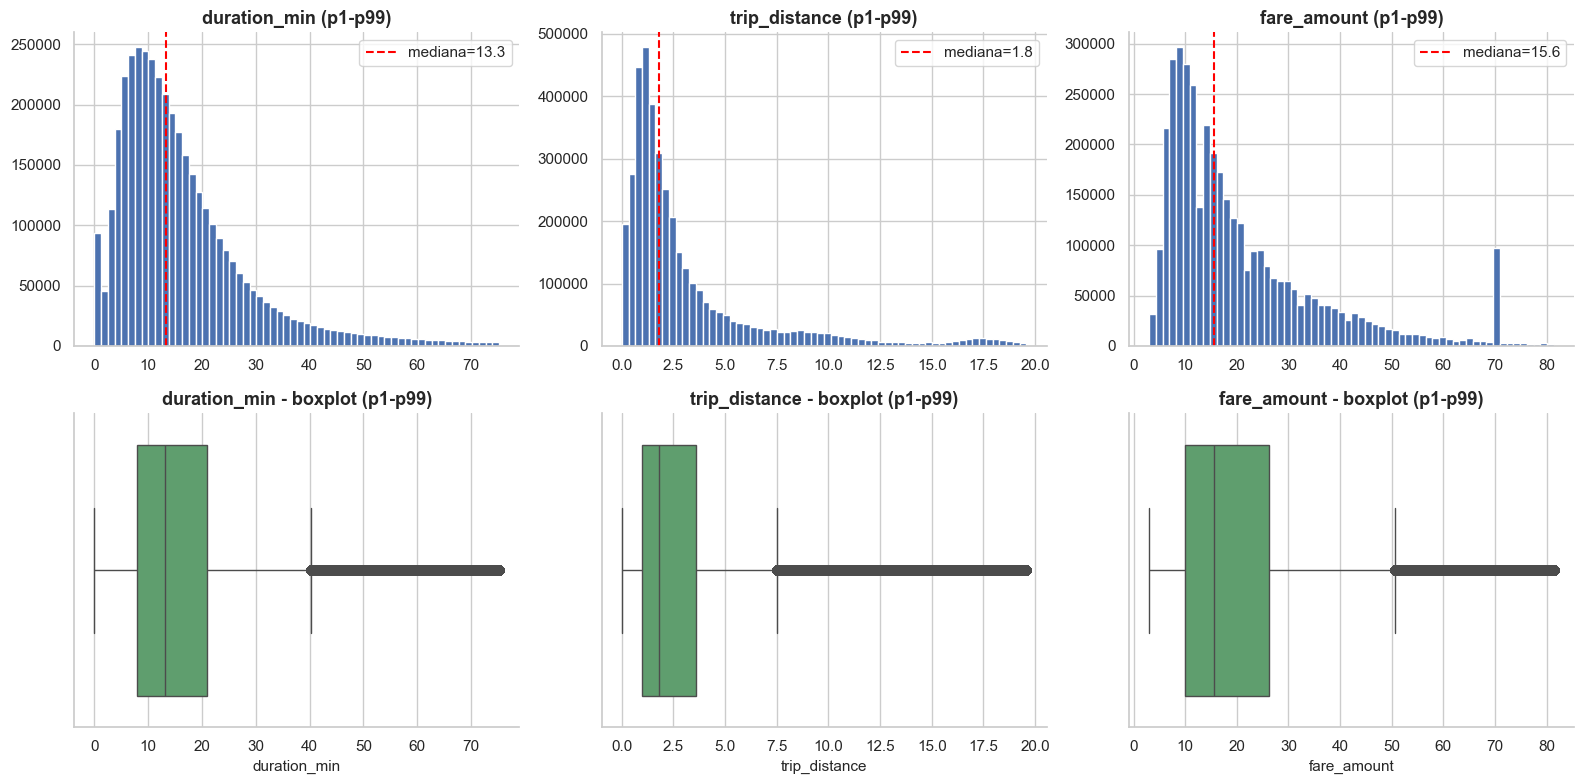

In [24]:
vis_cols = ['duration_min','trip_distance','fare_amount']
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for j, c in enumerate(vis_cols):
    s = df[c]
    s_clip = s[(s >= s.quantile(.01)) & (s <= s.quantile(.99))]
    ax[0, j].hist(s_clip, bins=60, color='#4C72B0', edgecolor='white')
    ax[0, j].axvline(s.median(), color='red', ls='--', label=f'mediana={s.median():.1f}')
    ax[0, j].set_title(f'{c} (p1-p99)'); ax[0, j].legend()
    sns.boxplot(x=s_clip, ax=ax[1, j], color='#55A868')
    ax[1, j].set_title(f'{c} - boxplot (p1-p99)')
plt.tight_layout(); plt.show()

**Interpretación.** Las tres variables tienen **distribución asimétrica a derecha** (sesgo positivo): la mayoría de los viajes son cortos/baratos y hay una cola larga de viajes largos. La mediana (línea roja) queda muy por debajo de la cola, confirmando por qué la media no es representativa.


### 2.2 Variables categóricas

Distribución de métodos de pago, tarifas y proveedores.


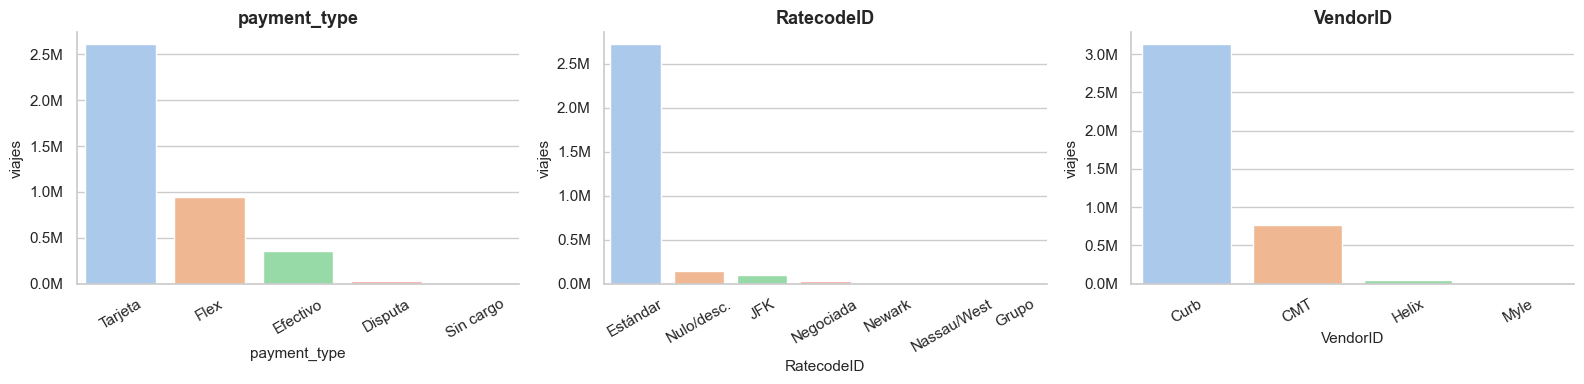

In [25]:
import matplotlib.ticker as mtick
mapas = {
    'payment_type': {0:'Flex',1:'Tarjeta',2:'Efectivo',3:'Sin cargo',4:'Disputa',5:'Desc.',6:'Anulado'},
    'RatecodeID':   {1:'Estándar',2:'JFK',3:'Newark',4:'Nassau/West',5:'Negociada',6:'Grupo',99:'Nulo/desc.'},
    'VendorID':     {1:'CMT',2:'Curb',6:'Myle',7:'Helix'},
}
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for j, c in enumerate(mapas):
    vc = df[c].map(mapas[c]).value_counts()
    sns.barplot(x=vc.index, y=vc.values, hue=vc.index, ax=ax[j], palette='pastel', legend=False)
    ax[j].set_title(c); ax[j].set_ylabel('viajes')
    ax[j].tick_params(axis='x', rotation=30)
    ax[j].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.tight_layout(); plt.show()

**Interpretación.** Predomina el pago con **tarjeta (66%)**, seguido de Flex Fare (24%) y efectivo (9%). En tarifa, casi todo es **rate estándar**; el proveedor **Curb (VendorID=2) concentra ~79%** de los viajes. Son variables muy desbalanceadas, dato a tener en cuenta si se usaran como features categóricas.


### 2.3 Patrones temporales

Viajes por hora del día y mapa de calor hora × día de semana.


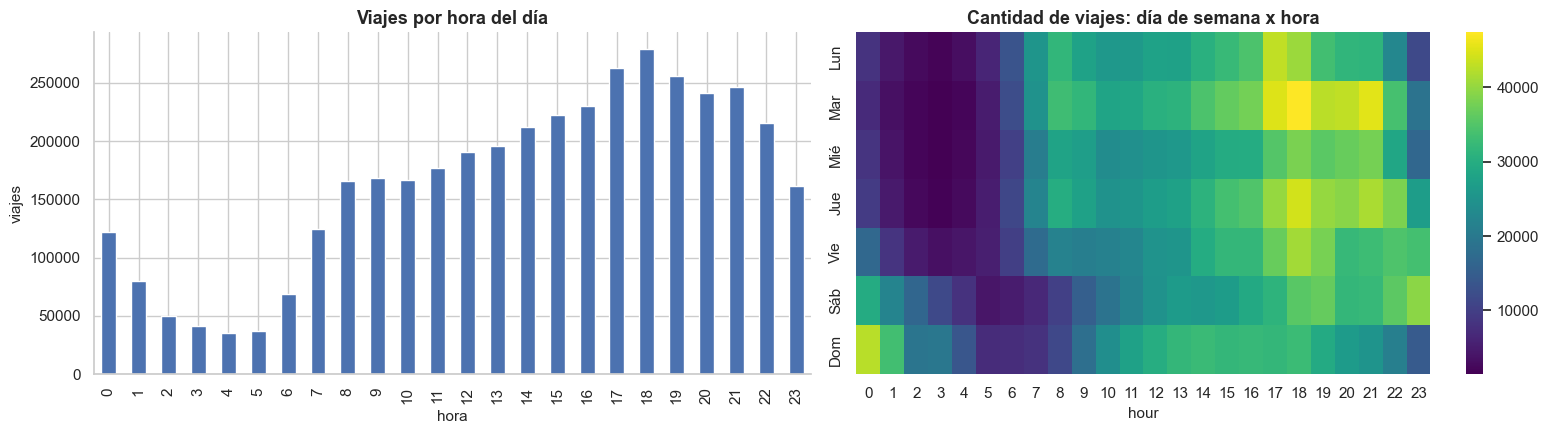

In [26]:
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['dow']  = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Lunes
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
df.groupby('hour').size().plot(kind='bar', ax=ax[0], color='#4C72B0')
ax[0].set_title('Viajes por hora del día'); ax[0].set_xlabel('hora'); ax[0].set_ylabel('viajes')
piv = df.pivot_table(index='dow', columns='hour', values='duration_min', aggfunc='size')
piv.index = dias
sns.heatmap(piv, cmap='viridis', ax=ax[1])
ax[1].set_title('Cantidad de viajes: día de semana x hora')
plt.tight_layout(); plt.show()

**Interpretación.** La demanda tiene un patrón diario marcado: **mínimo a las ~4 a.m.** y **pico a las ~18 h** (salida laboral). El heatmap muestra además el pico nocturno de los fines de semana (viernes/sábado de madrugada). La **hora** y el **día de semana** son, por lo tanto, candidatos como features: el horario condiciona el tipo de viaje (tráfico, salidas nocturnas, fines de semana) y puede asociarse a cuánta propina se deja.


### 2.4 Correlaciones entre variables numéricas

Comparamos Pearson (no robusta) con Spearman y Kendall sobre una muestra.


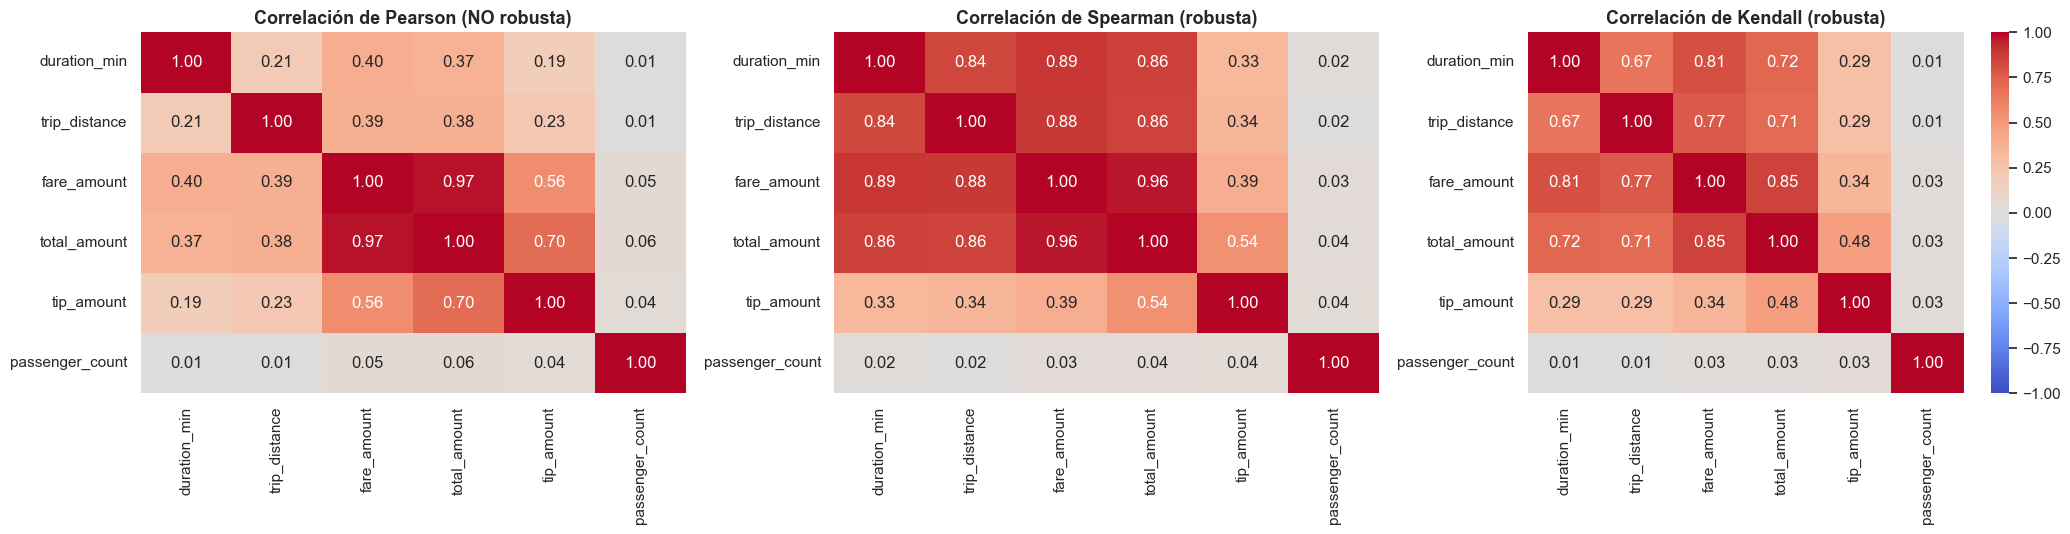

In [27]:
corr_cols = ['duration_min','trip_distance','fare_amount','total_amount','tip_amount','passenger_count']
samp = df[corr_cols].dropna().sample(200_000, random_state=0)
metodos = [('pearson','Pearson (NO robusta)'), ('spearman','Spearman (robusta)'), ('kendall','Kendall (robusta)')]
fig, ax = plt.subplots(1, 3, figsize=(21, 5.5))
for j, (m, titulo) in enumerate(metodos):
    sns.heatmap(samp.corr(method=m), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax[j], cbar=(j == 2))
    ax[j].set_title(f'Correlación de {titulo}')
plt.tight_layout(); plt.show()

**Interpretación (caso de estadística robusta).** La **Pearson** entre `duration_min` y `trip_distance` da prácticamente **0** sobre los datos crudos, lo cual es absurdo (a más distancia, más duración). El culpable son los outliers extremos (distancias de cientos de miles de millas): Pearson asume relación lineal y es muy sensible a valores extremos.

Las dos medidas **robustas** revelan la relación real:

- **Spearman** (correlación de rangos, detecta relación monótona): **0,79** duración–distancia y **0,85** duración–tarifa.
- **Kendall** (concordancia de pares, también robusta): **0,63** duración–distancia y **0,72** duración–tarifa.

Kendall suele dar valores absolutos menores que Spearman para la misma asociación (compara pares concordantes/discordantes en vez de correlacionar rangos), pero ambas cuentan la misma historia: la asociación es **fuerte y positiva**, y Pearson la ocultaba por completo. Ante colas pesadas, conviene apoyarse en medidas robustas.

Otro hallazgo con implicancia directa para nuestro target: `total_amount` **incluye la propina dentro de su suma** (total = tarifa + propina + peajes + recargos). Usarlo para predecir `tip_amount` sería **fuga de información** pura (el target está metido en el feature). Por eso nos quedamos con `fare_amount` —la tarifa sin la propina— como predictor, y descartamos `total_amount`.


### 2.5 Relación numérica × categórica: violin plots

El violin plot combina un **boxplot** con la **estimación de densidad (KDE)**: muestra mediana, cuartiles y, además, la *forma* completa de la distribución por categoría. (Un swarmplot no es viable acá: con 3,9M de puntos el gráfico sería ilegible y carísimo de renderizar; es una técnica para muestras chicas.)


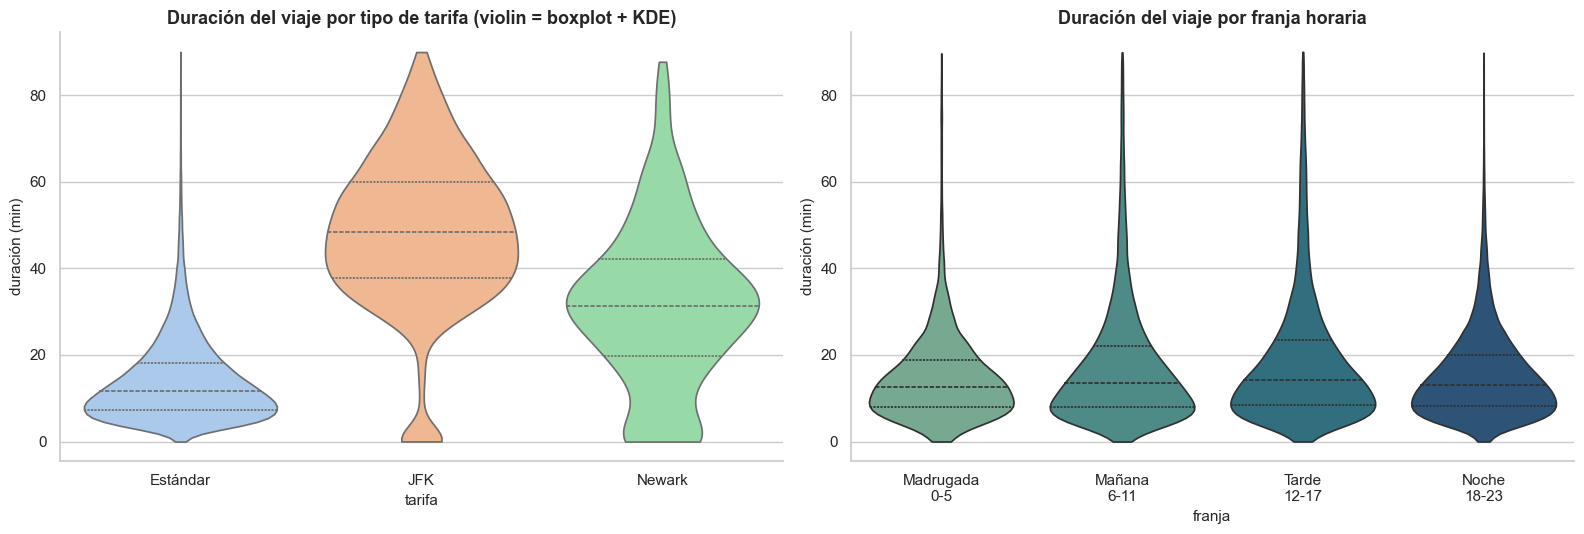

In [28]:
# Violin plots: duración según tipo de tarifa y según franja horaria
sub = df[(df['duration_min'] > 0) & (df['duration_min'] <= 90)].copy()
sub['tarifa'] = sub['RatecodeID'].map({1:'Estándar', 2:'JFK', 3:'Newark'})
sub['franja'] = pd.cut(sub['hour'], bins=[-1,5,11,17,23],
                       labels=['Madrugada\n0-5','Mañana\n6-11','Tarde\n12-17','Noche\n18-23'])

muestra = sub.dropna(subset=['tarifa']).sample(150_000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
sns.violinplot(data=muestra, x='tarifa', y='duration_min', hue='tarifa', order=['Estándar','JFK','Newark'],
               palette='pastel', inner='quartile', cut=0, ax=ax[0], legend=False)
ax[0].set_title('Duración del viaje por tipo de tarifa (violin = boxplot + KDE)')
ax[0].set_ylabel('duración (min)')
sns.violinplot(data=sub.sample(150_000, random_state=0), x='franja', y='duration_min', hue='franja',
               palette='crest', inner='quartile', cut=0, ax=ax[1], legend=False)
ax[1].set_title('Duración del viaje por franja horaria')
ax[1].set_ylabel('duración (min)')
plt.tight_layout(); plt.show()

**Interpretación.** El violín izquierdo expone la mayor diferencia de todo el EDA: los viajes con tarifa **JFK tienen mediana de ~48 min** (distribución ancha y simétrica alrededor de la mediana) contra **~11,7 min de la tarifa estándar** (concentrada abajo, con cola superior). **Newark queda en el medio (~32 min)**. El tipo de tarifa codifica implícitamente el destino aeropuerto → es un predictor potente de la duración. (Contexto: **JFK** es el aeropuerto internacional, en Queens, a ~17 millas del centro de Manhattan; **Newark** está en New Jersey, cruzando el río Hudson — ambos con tarifas especiales de taxímetro, distintas de la tarifa estándar por reloj.)

Por franja horaria las **medianas son parecidas (12,4–14,2 min)** pero la *forma* cambia: la **tarde (12–17 h)** tiene el cuerpo más desplazado hacia arriba y cola más pesada (tráfico), mientras la madrugada se concentra en viajes cortos. Esto sugiere que la hora aporta señal sobre la duración más allá de la distancia — algo que un boxplot solo insinuaría y el violín hace visible.


In [29]:
# Evidencia cuantitativa del efecto tráfico: velocidad efectiva mediana por franja
vel = sub[(sub['duration_min'] > 1) & (sub['trip_distance'] > 0) & (sub['trip_distance'] <= 30)].copy()
vel['vel_mph'] = vel['trip_distance'] / (vel['duration_min']/60)
vel = vel[vel['vel_mph'] < 60]  # descarta velocidades físicamente imposibles
vel.groupby('franja', observed=True)['vel_mph'].median().round(1).rename('velocidad mediana (mph)').to_frame()

,velocidad mediana (mph)
franja,
Madrugada\n0-5,12.8
Mañana\n6-11,9.4
Tarde\n12-17,8.2
Noche\n18-23,10.0


**Interpretación.** La velocidad efectiva mediana cae de **12,8 mph en la madrugada a 8,2 mph en la tarde** (−36%): un mismo trayecto tarda ~50% más en hora pico. Esto confirma cuantitativamente lo que los violines insinuaban: la **hora del día aporta señal propia, independiente de la distancia**, y justifica las features horarias del modelo.


### 2.6 Relación multivariada: distancia × duración

Scatter y hexbin con tarifa como categoría.


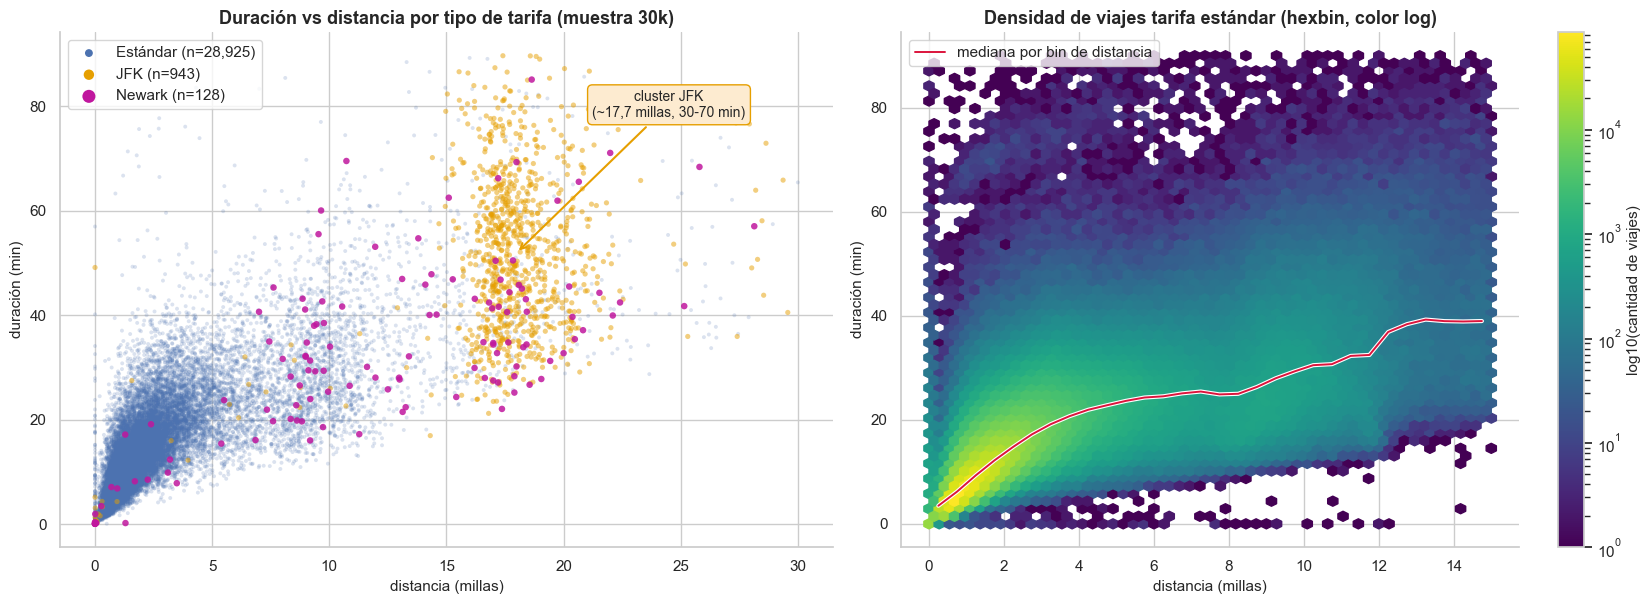

In [30]:
# Relación multivariada: dos numéricas + una categórica como hue
fig, ax = plt.subplots(1, 2, figsize=(17, 6.2))

# Panel izquierdo: scatter por capas -> la clase mayoritaria de fondo y las minoritarias
# encima, con colores bien separados en tono (azul / naranja / magenta)
muestra2 = sub.dropna(subset=['tarifa']).sample(30_000, random_state=1)
muestra2 = muestra2[muestra2['trip_distance'] <= 30]
estilos = {  # color, alpha, tamaño: más opacas y grandes las clases con menos puntos
    'Estándar': ('#4C72B0', 0.20,  8),
    'JFK':      ('#E69F00', 0.50, 14),
    'Newark':   ('#C0179E', 0.85, 22),
}
for tarifa, (color, alpha, s) in estilos.items():
    g = muestra2[muestra2['tarifa'] == tarifa]
    ax[0].scatter(g['trip_distance'], g['duration_min'], c=color, alpha=alpha, s=s,
                  label=f'{tarifa} (n={len(g):,})', edgecolors='none')
ax[0].annotate('cluster JFK\n(~17,7 millas, 30-70 min)', xy=(18, 52), xytext=(24.5, 78),
               fontsize=10, ha='center',
               arrowprops=dict(arrowstyle='->', color='#E69F00', lw=1.5),
               bbox=dict(boxstyle='round,pad=0.35', fc='#FDEBD0', ec='#E69F00'))
ax[0].set_title('Duración vs distancia por tipo de tarifa (muestra 30k)')
ax[0].set_xlabel('distancia (millas)'); ax[0].set_ylabel('duración (min)')
leg = ax[0].legend(loc='upper left', markerscale=2)
for lh in leg.legend_handles: lh.set_alpha(1)

# Panel derecho: hexbin con color logarítmico -> densidad real, sin overplotting
est = sub[(sub['tarifa'] == 'Estándar') & (sub['trip_distance'] <= 15)]
hb = ax[1].hexbin(est['trip_distance'], est['duration_min'], gridsize=55, bins='log', cmap='viridis')
# tendencia central robusta: mediana de duración por bin de distancia
bins_d = pd.cut(est['trip_distance'], bins=np.arange(0, 15.5, 0.5))
med = est.groupby(bins_d, observed=True)['duration_min'].median()
centros = [iv.mid for iv in med.index]
ax[1].plot(centros, med.values, color='white', lw=3)
ax[1].plot(centros, med.values, color='crimson', lw=1.4, label='mediana por bin de distancia')
fig.colorbar(hb, ax=ax[1], label='log10(cantidad de viajes)')
ax[1].set_title('Densidad de viajes tarifa estándar (hexbin, color log)')
ax[1].set_xlabel('distancia (millas)'); ax[1].set_ylabel('duración (min)')
ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

**Interpretación.** El scatter (izquierda) confirma la relación **monótona positiva** entre distancia y duración que Pearson no detectaba, y el **cluster JFK** queda anotado: viajes de ~17,7 millas con 30–70 min, la firma del trayecto Manhattan–aeropuerto.

El scatter, sin embargo, sufre **overplotting**: con tantos puntos superpuestos no se distingue dónde está la masa. El **hexbin con escala de color logarítmica** (derecha) lo resuelve y muestra que el grueso del negocio son viajes de **1–3 millas y 5–20 minutos**. La curva roja —**mediana de duración por bin de distancia**, otra aplicación de estadística robusta— crece de forma sostenida y casi lineal, pero la dispersión vertical alrededor de ella (un mismo trayecto puede tardar el doble según el tráfico) muestra cuánta información aportan la **hora** y la **zona** más allá de la distancia —features que después reutilizamos para modelar la propina.


### 2.7 Dimensión espacial: zonas TLC con nombres reales

`PULocationID`/`DOLocationID` son códigos. Para interpretarlos los cruzamos con la **tabla oficial de zonas de TLC** (`taxi_zone_lookup.csv`, agregada al repo), que mapea cada ID a su barrio y borough.

> **Mini-guía geográfica para leer los resultados.** Manhattan se divide informalmente en **Downtown** (extremo sur de la isla: Financial District, TriBeCa, SoHo, los Villages — finanzas y vida nocturna), **Midtown** (centro: Times Square, Penn Station, Grand Central — oficinas, comercio, turismo y los grandes nodos de transporte) y **Uptown** (norte: Upper East / Upper West Side — residencial de alto poder adquisitivo; más al norte, Harlem). Los tres aeropuertos del área: **JFK** (Queens, el internacional principal, a ~17 millas del centro), **LaGuardia / LGA** (Queens, mayormente vuelos domésticos, a ~9 millas) y **Newark / EWR** (en New Jersey, cruzando el río Hudson: queda *fuera* de NYC y por eso el taxímetro le aplica una tarifa especial, `RatecodeID=3`).


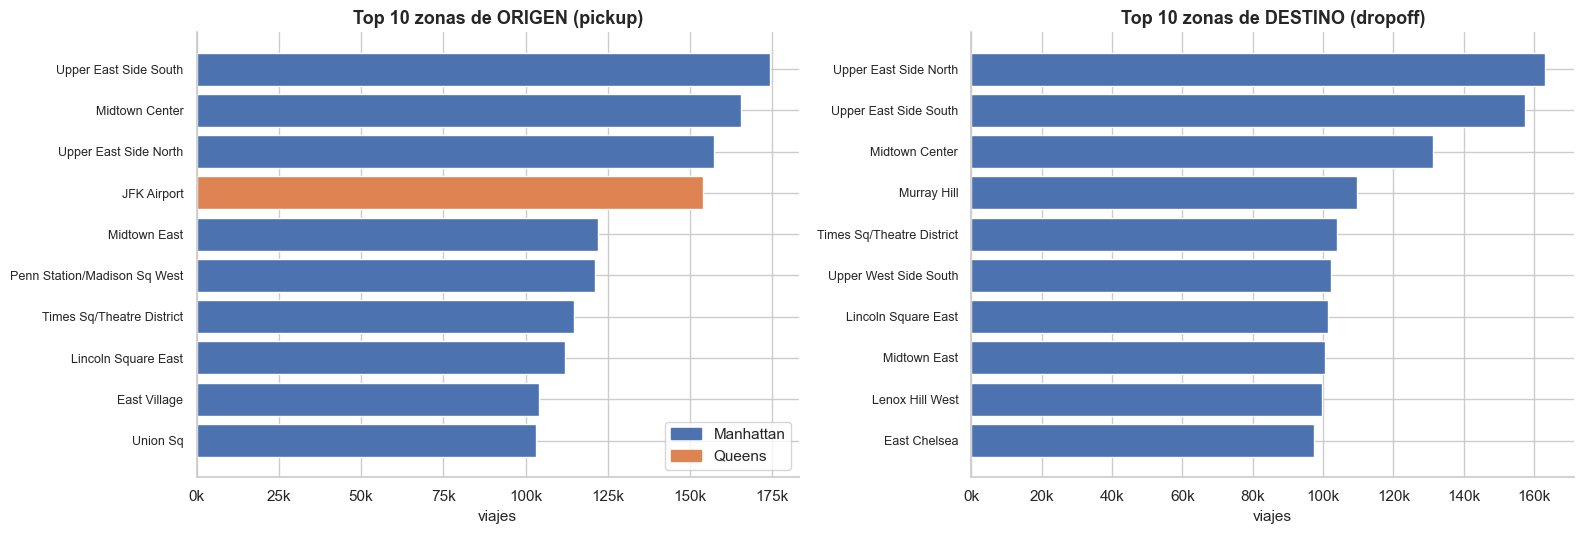

Pickups en Manhattan: 85.8%
Pickups en aeropuertos (JFK + LaGuardia): 6.3%
Cardinalidad de zonas: 261 orígenes / 260 destinos distintos


In [31]:
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

zonas = pd.read_csv(Path('dataset') / 'taxi_zone_lookup.csv').set_index('LocationID')
colores_boro = {'Manhattan':'#4C72B0', 'Queens':'#DD8452', 'Brooklyn':'#55A868', 'Bronx':'#C44E52'}

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
for j, (col, titulo) in enumerate([('PULocationID','Top 10 zonas de ORIGEN (pickup)'),
                                   ('DOLocationID','Top 10 zonas de DESTINO (dropoff)')]):
    top = df[col].value_counts().head(10)
    nombres = top.index.map(zonas['Zone'])
    boros   = top.index.map(zonas['Borough'])
    ax[j].barh(range(len(top)), top.values, color=[colores_boro.get(b,'gray') for b in boros])
    ax[j].set_yticks(range(len(top))); ax[j].set_yticklabels(nombres, fontsize=9)
    ax[j].invert_yaxis()
    ax[j].set_title(titulo); ax[j].set_xlabel('viajes')
    ax[j].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax[0].legend(handles=[mpatches.Patch(color=c, label=b) for b,c in colores_boro.items()
                      if b in ('Manhattan','Queens')], loc='lower right')
plt.tight_layout(); plt.show()

pu_boro = df['PULocationID'].map(zonas['Borough'])
print(f"Pickups en Manhattan: {100*pu_boro.eq('Manhattan').mean():.1f}%")
print(f"Pickups en aeropuertos (JFK + LaGuardia): {100*df['PULocationID'].isin([132,138]).mean():.1f}%")
print(f"Cardinalidad de zonas: {df['PULocationID'].nunique()} orígenes / {df['DOLocationID'].nunique()} destinos distintos")

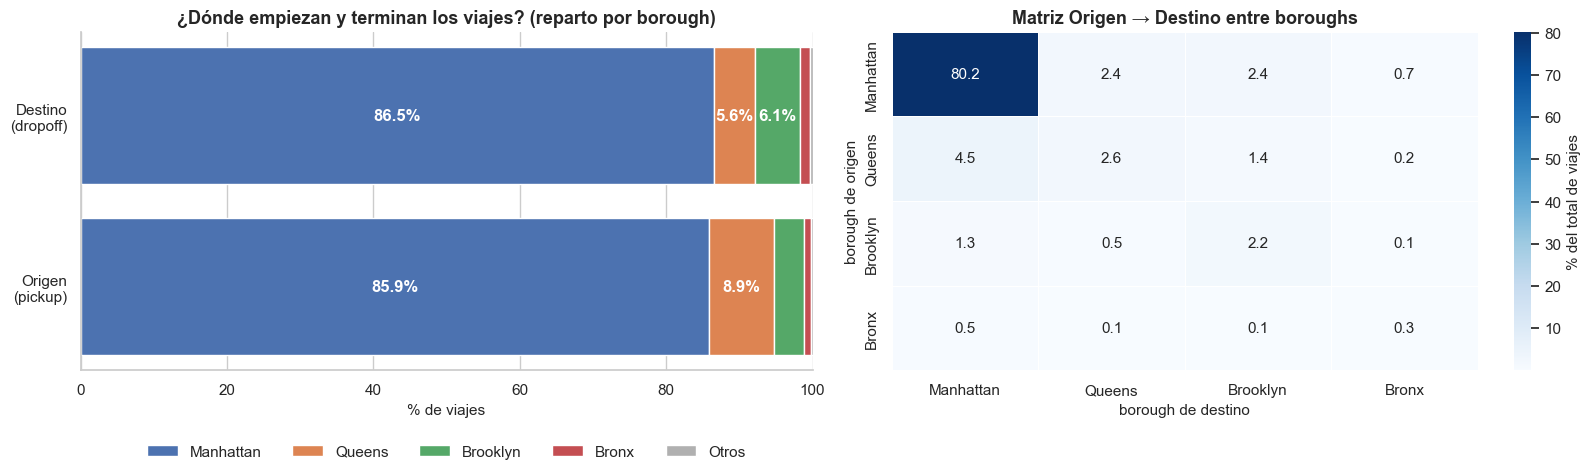

In [32]:
# La evidencia visual del Manhattan-centrismo: proporciones por borough y matriz O-D
pu_b = df['PULocationID'].map(zonas['Borough'])
do_b = df['DOLocationID'].map(zonas['Borough'])
orden = ['Manhattan','Queens','Brooklyn','Bronx','Otros']
colores = {'Manhattan':'#4C72B0','Queens':'#DD8452','Brooklyn':'#55A868','Bronx':'#C44E52','Otros':'#B0B0B0'}

def shares(s):
    v = s.value_counts(normalize=True)*100
    v = v.reindex(orden[:-1]).fillna(0)
    v['Otros'] = 100 - v.sum()
    return v

fig, ax = plt.subplots(1, 2, figsize=(16.5, 5))

# Panel izquierdo: barras 100% apiladas -> el reparto completo en una sola mirada
filas = {'Origen\n(pickup)': shares(pu_b), 'Destino\n(dropoff)': shares(do_b)}
for yi, (lbl, v) in enumerate(filas.items()):
    izq = 0
    for b in orden:
        ax[0].barh(lbl, v[b], left=izq, color=colores[b], label=b if yi == 0 else None)
        if v[b] > 5:
            ax[0].text(izq + v[b]/2, yi, f'{v[b]:.1f}%', ha='center', va='center',
                       color='white', fontweight='bold', fontsize=12)
        izq += v[b]
ax[0].set_xlim(0, 100); ax[0].set_xlabel('% de viajes')
ax[0].set_title('¿Dónde empiezan y terminan los viajes? (reparto por borough)')
ax[0].legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)

# Panel derecho: matriz Origen -> Destino entre boroughs (% del total de viajes)
od = (pd.crosstab(pu_b, do_b, normalize=True)*100).reindex(index=orden[:-1], columns=orden[:-1])
sns.heatmap(od, annot=True, fmt='.1f', cmap='Blues', linewidths=.5,
            annot_kws={'fontsize': 11}, cbar_kws={'label': '% del total de viajes'}, ax=ax[1])
ax[1].set_title('Matriz Origen → Destino entre boroughs')
ax[1].set_xlabel('borough de destino'); ax[1].set_ylabel('borough de origen')
plt.tight_layout(); plt.show()

**Interpretación.** El negocio del yellow cab es **abrumadoramente Manhattan-céntrico**, y los tres gráficos lo evidencian en niveles distintos:

- Las **barras apiladas** muestran el reparto completo: **85,9% de los orígenes y 86,5% de los destinos** son Manhattan; Queens aporta el segundo bloque de orígenes (8,9%) casi enteramente por sus dos aeropuertos.
- La **matriz Origen → Destino** lo sella: el **80,2% de *todos* los viajes empieza y termina dentro de Manhattan**. El segundo flujo es Queens → Manhattan (4,5%) — la vuelta del aeropuerto a la ciudad — y los flujos que no tocan Manhattan son marginales (Brooklyn → Brooklyn, 2,2%).
- El **top-10 por zona** pone nombres: Upper East Side, Midtown y los nodos de transporte (Penn Station, Times Sq) encabezan, con **JFK como 4º origen (3,9%)** pero ausente de los destinos top — el yellow cab domina la *salida* del aeropuerto más que la llegada.

Para el modelo, esto confirma a la zona como feature valiosa pero plantea un desafío: con **~260 valores distintos** y fuerte concentración, las zonas tienen **alta cardinalidad** → no conviene one-hot puro; en la etapa de *feature engineering* (Azul) convendrá *frequency/target encoding* o agrupar por borough.


## 3. Planteo del problema de ML supervisado

### 3.1 Definición del problema

- **Target:** `tip_amount` (propina en USD). Variable numérica continua nativa del dataset.
- **Tipo de problema:** regresión supervisada.
- **Objetivo:** predecir el monto de propina que dejará el pasajero en viajes pagados con tarjeta.
- **Justificación:** problema realista para analizar ingresos adicionales y comportamiento de pasajeros. La propina suele decidirse como porcentaje de la tarifa, no como monto fijo.
- **Alcance / universo:** el diccionario TLC indica que `tip_amount` se registra automáticamente solo en pagos con tarjeta; en efectivo figura como 0 (MNAR). Por eso el modelado se restringe a `payment_type == 1`.
- **Desafíos:** outliers (valores negativos o propinas muy altas), multicolinealidad entre variables de tarifa/distancia, y posibles patrones geográficos u horarios explotables como features.


### 3.2 Exploración visual del target (universo tarjeta)


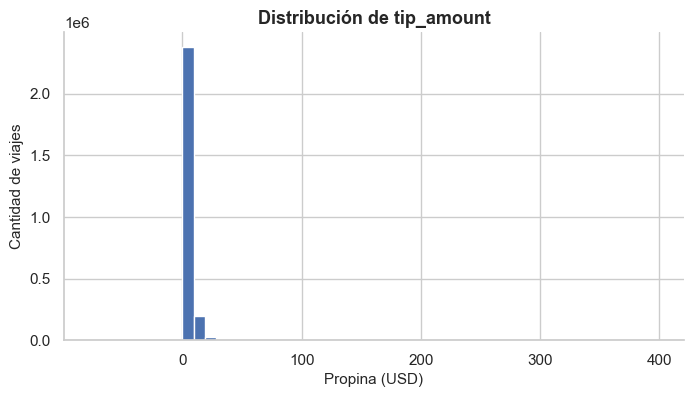

In [33]:
# Distribución de tip_amount

df_card = df[df["payment_type"] == 1].copy()

plt.figure(figsize=(8,4))
plt.hist(df_card["tip_amount"], bins=50)
plt.title("Distribución de tip_amount")
plt.xlabel("Propina (USD)")
plt.ylabel("Cantidad de viajes")
plt.show()


# En este gráfico, podemos observar que casi todas las propinas están concentradas muy cerca de 0, mientras que hay unas pocas que llegan hasta casi 400 USD.

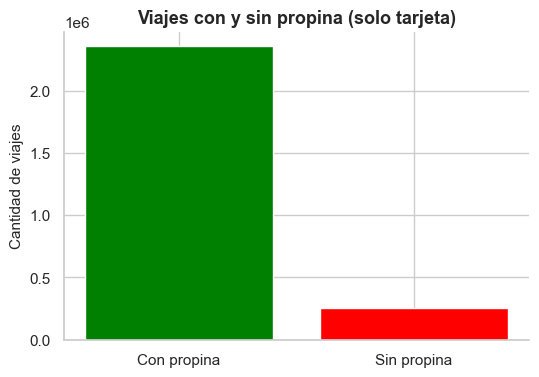

In [34]:
# Muestra de viajes pagados con tarjeta que dejaron propina vs que no dejaron

con_propina = (df_card["tip_amount"] > 0).sum()
sin_propina = (df_card["tip_amount"] == 0).sum()

plt.figure(figsize=(6, 4))
plt.bar(["Con propina", "Sin propina"], [con_propina, sin_propina],
        color=["green", "red"])
plt.title("Viajes con y sin propina (solo tarjeta)")
plt.ylabel("Cantidad de viajes")
plt.show()

# La mayoría de los viajes abonados con tarjeta registran una propina, aunque tambien existen viajes sin propina.

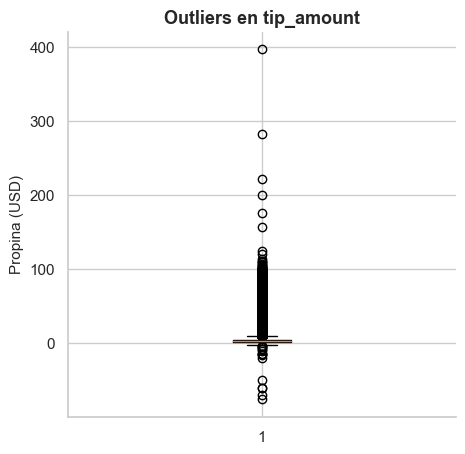

Valores negativos: 32
Valor máximo: $397.00


In [35]:
# Outliers en tip_amount

plt.figure(figsize=(5, 5))
plt.boxplot(df_card["tip_amount"].dropna())
plt.title("Outliers en tip_amount")
plt.ylabel("Propina (USD)")
plt.show()

print(f"Valores negativos: {(df_card['tip_amount'] < 0).sum()}")
print(f"Valor máximo: ${df_card['tip_amount'].max():.2f}")

# Se identifican outliers extremos en tip_amount, con propinas de monto elevado. Además, hay viajes con propina negativa, lo que podría indicar ajustes contables o errores en el registro de datos.


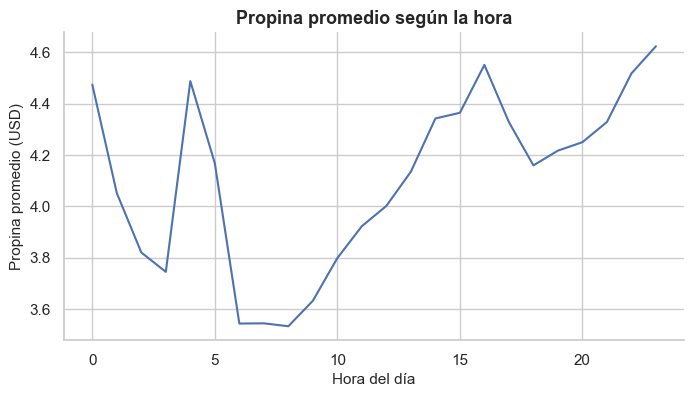

In [36]:
# Relación entre tip_amount y hora del día

df_card["pickup_hour"] = df_card["tpep_pickup_datetime"].dt.hour

df_card.groupby("pickup_hour")["tip_amount"].mean().plot(figsize=(8,4))
plt.title("Propina promedio según la hora")
plt.xlabel("Hora del día")
plt.ylabel("Propina promedio (USD)")
plt.show()

# La propina promedio es más baja en la mañana (~3,5 USD entre las 6 y 9 h, los viajes al trabajo)
# y sube a lo largo del día hasta el pico de la noche (~4,6 USD a las 22-23 h), con un repunte
# llamativo en la madrugada (0-4 h). La diferencia entre el mínimo y el máximo es de ~1 USD (un 31%)

## 4. Preprocesamiento y limpieza del dataset

Primero restringimos el universo y limpiamos errores imposibles, luego **hacemos el split train/test**, y recién **después** ajustamos las transformaciones (imputación, outliers, escalado) **sobre el train** y las aplicamos al test, para evitar fuga de información.


### 4.1 Filtrado a pagos con tarjeta y limpieza de inconsistencias

Primero restringimos el dataset al **universo válido para el target** (tarjeta) y eliminamos lo **físicamente imposible o inservible** para predecir la propina. Los outliers *plausibles* no se borran acá: se winsorizan en 4.5.


In [37]:
# Universo de análisis: SOLO pagos con tarjeta (payment_type == 1).
# Motivo (ver sección 3): la propina en efectivo no se registra (MNAR); incluir efectivo
# entrenaría un proxy del medio de pago, no la conducta de propina.
df_card = df[df['payment_type'] == 1].copy()
n0 = len(df)
print(f'Viajes totales:      {n0:,}')
print(f'Viajes con tarjeta:  {len(df_card):,}  ({100*len(df_card)/n0:.1f}% del dataset)\n')

# Limpieza de registros imposibles / inservibles para el target tip_amount.
reglas = [
    ('duración en (0, 180] min',          (df_card['duration_min'] > 0) & (df_card['duration_min'] <= 180)),
    ('distancia en (0, 100] millas',      (df_card['trip_distance'] > 0) & (df_card['trip_distance'] <= 100)),
    ('fare >= 2.50 (tarifa base mínima)',  df_card['fare_amount'] >= 2.50),
    ('tip_amount >= 0',                    df_card['tip_amount'] >= 0),
    ('pickup en marzo 2026',               df_card['tpep_pickup_datetime'].between('2026-03-01','2026-03-31 23:59:59')),
]
n1 = len(df_card)
for nombre, cond in reglas:
    antes = len(df_card)
    df_card = df_card[cond.reindex(df_card.index).fillna(False)]
    print(f'{nombre:36s} -> elimina {antes-len(df_card):>8,} filas')
print('-'*64)
print(f'Filas finales: {len(df_card):,}  ({100*len(df_card)/n1:.1f}% del universo tarjeta)')

Viajes totales:      3,952,451
Viajes con tarjeta:  2,608,830  (66.0% del dataset)

duración en (0, 180] min             -> elimina   43,410 filas
distancia en (0, 100] millas         -> elimina   19,572 filas
fare >= 2.50 (tarifa base mínima)    -> elimina      136 filas
tip_amount >= 0                      -> elimina        0 filas
pickup en marzo 2026                 -> elimina       15 filas
----------------------------------------------------------------
Filas finales: 2,545,697  (97.6% del universo tarjeta)


#### Filtros físicos adicionales (coherencia cinemática y tarifaria)

Sumamos dos reglas de la literatura de limpieza del dataset TLC, que descartan registros **corruptos** sin tocar los outliers plausibles (esos se winsorizan en 4.5):

- **(a) Velocidad imposible:** descartamos viajes con velocidad media `distancia / duración > 100 mph`. En una ciudad crónicamente congestionada es físicamente imposible → delata un error de GPS o de reloj a bordo.
- **(b) Coherencia tarifa–distancia (solo tarifa estándar):** para `RatecodeID == 1` el taxímetro acumula ~US$2,50 por milla; si la tarifa cobrada es menor que `2,50 × distancia`, la distancia reportada está corrupta (error de GPS). **El filtro se desactiva para tarifas planas o negociadas** (JFK=2, Newark=3, negociada=5, etc.), donde el precio *no* depende de la distancia y forzar esta relación eliminaría datos válidos.


In [38]:
# Filtros físicos adicionales (literatura de limpieza del dataset TLC)
# (a) Velocidad imposible: ningún viaje urbano sostiene > 100 mph promedio.
n_prev = len(df_card)
vel_mph = df_card['trip_distance'] / (df_card['duration_min'] / 60)   # millas por hora
df_card = df_card[vel_mph <= 100]
print(f'(a) velocidad media > 100 mph                 -> elimina {n_prev-len(df_card):>8,} filas')

# (b) Coherencia tarifa-distancia SOLO para tarifa estándar (RatecodeID == 1).
#     Las tarifas PLANAS/negociadas (JFK=2, Newark=3, negociada=5...) NO siguen
#     esta relación, por eso quedan EXCLUIDAS del filtro.
n_prev = len(df_card)
es_estandar  = df_card['RatecodeID'] == 1
incoherente  = es_estandar & (df_card['fare_amount'] < 2.50 * df_card['trip_distance'])
df_card = df_card[~incoherente]
print(f'(b) tarifa estándar incoherente con distancia -> elimina {n_prev-len(df_card):>8,} filas')
print('-'*64)
print(f'Filas finales tras filtros físicos: {len(df_card):,}')

# Chequeo de duplicados: no hay viajes repetidos.
print(f'\nFilas 100% duplicadas: {df_card.duplicated().sum():,}')


(a) velocidad media > 100 mph                 -> elimina      354 filas
(b) tarifa estándar incoherente con distancia -> elimina       68 filas
----------------------------------------------------------------
Filas finales tras filtros físicos: 2,545,275

Filas 100% duplicadas: 0


### 4.2 Definición del target: `tip_amount`

El target es la propina en dólares (`tip_amount`), una columna nativa del dataset: no requiere derivación ni transformación. Solo verificamos su distribución en el universo de tarjeta antes de seguir.


In [39]:
# Target = tip_amount (propina en USD). No se deriva: es una columna nativa del dataset.
print('Distribución de tip_amount (propina en USD, universo tarjeta):')

print(df_card['tip_amount'].describe(percentiles=[.25, .5, .75, .9, .99]).round(2))
print(f"\nViajes con propina > 0: {(df_card['tip_amount'] > 0).mean()*100:.1f}%  "
      f"(en tarjeta la propina sí se registra)")


Distribución de tip_amount (propina en USD, universo tarjeta):
count    2545275.00
mean           4.14
std            4.03
min            0.00
25%            2.00
50%            3.20
75%            4.83
90%            8.11
99%           18.98
max          222.00
Name: tip_amount, dtype: float64

Viajes con propina > 0: 90.2%  (en tarjeta la propina sí se registra)


### 4.3 Split train / test (antes de transformar)

Se realiza el split primero antes de imputar o escalar para evitar data-leakage.

In [40]:
from sklearn.model_selection import train_test_split

features = ['trip_distance','duration_min','fare_amount','PULocationID','DOLocationID',
            'passenger_count','hour','dow','RatecodeID','VendorID']
target = 'tip_amount'

X = df_card[features].copy()
y = df_card[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'Features: {features}')
print(f'Target:   {target}  (excluido por leakage: total_amount, que contiene la propina)')


Train: 2,036,220 filas | Test: 509,055 filas
Features: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']
Target:   tip_amount  (excluido por leakage: total_amount, que contiene la propina)


### 4.4 Valores faltantes

En el dataset completo, 5 columnas tienen 23,93% de faltantes, y en 1.3 vimos que son **estructurales (MAR)**: faltan exactamente en los viajes Flex Fare (`payment_type == 0`). Como nuestro universo es **solo tarjeta** (`payment_type == 1`), esos faltantes quedan **fuera por construcción**. Lo verificamos antes de seguir, en lugar de imputar a ciegas.


In [41]:
# Los faltantes estructurales vivían 100% en Flex Fare (payment_type==0), que ya
# quedó fuera del universo tarjeta. Verificamos que no queda ninguno por tratar.
nulos_train = X_train.isna().sum()
print('Faltantes por columna en el universo tarjeta (post-filtro):')
print(nulos_train[nulos_train > 0] if nulos_train.sum() else '  Sin faltantes: 0 en todas las columnas.')
print(f'\nTotal de NaN -> train: {int(X_train.isna().sum().sum())} | test: {int(X_test.isna().sum().sum())}')
# => No se requiere imputación. Tampoco agregamos bandera de faltante: sería
#    constante (todo 0) en este universo, una feature sin información.


Faltantes por columna en el universo tarjeta (post-filtro):
  Sin faltantes: 0 en todas las columnas.

Total de NaN -> train: 0 | test: 0


### 4.5 Tratamiento de outliers

Los errores imposibles ya se eliminaron en 4.1. A los outliers plausibles los acotamos (winsorización), pero con un criterio pensado para el target **en dólares**:

- **Features continuas:** las acotamos por **percentiles (p1–p99)** del train, no por IQR×1,5. En este universo el IQR es muy estrecho y el recorte clásico borraría los viajes largos y caros (aeropuertos), que son válidos y donde se concentran las propinas altas: justo la señal que el modelo necesita.
- **Target `tip_amount`:** solo recortamos la **cola superior extrema (p99.5 del train)**, que corresponde a propinas erróneas de cientos de dólares. **No usamos IQR**: cliparía ~9% de propinas perfectamente válidas (viajes caros).


In [42]:
# === Winsorización de features continuas (límites p1–p99 del TRAIN) ===
# Usamos percentiles en vez de IQR*1.5: en este universo el IQR recortaría los
# viajes largos/caros (aeropuertos), legítimos y donde están las propinas altas.
print('Winsorización de features (cap p1–p99, límites del train):')
cols_winsor = ['trip_distance', 'duration_min', 'fare_amount']
for c in cols_winsor:
    lo, hi = X_train[c].quantile(.01), X_train[c].quantile(.99)
    for split in (X_train, X_test):
        split[c] = split[c].clip(lower=max(lo, 0), upper=hi)
    print(f'  {c:14s} -> [{max(lo, 0):.2f}, {hi:.2f}]')

# Target: solo recortamos la cola superior extrema (errores tipo $397).
# NO usamos IQR: cliparía ~9% de propinas altas que son válidas (viajes caros).
y_hi = y_train.quantile(.995)
y_train = y_train.clip(lower=0, upper=y_hi)
y_test  = y_test.clip(lower=0, upper=y_hi)
print(f'\nTarget tip_amount -> [0.00, {y_hi:.2f}]  (cap p99.5 del train)')

# === (Opcional) Por qué no usamos log1p: comparación de asimetría ===
# Se mide sobre df_card (valores aún sin winsorizar). log1p simetriza más,
# pero cambia las unidades; winsorizar conserva los dólares/millas.
print('\nAsimetría (skew) — cuanto más cerca de 0, más simétrica:')
print(f"  {'variable':14s} {'cruda':>7s} {'winsor':>8s} {'log1p':>8s}")
for col in ['fare_amount', 'tip_amount', 'trip_distance']:
    s = df_card[col]
    lo, hi = s.quantile(.01), s.quantile(.99)
    print(f'  {col:14s} {s.skew():7.2f} {s.clip(lo, hi).skew():8.2f} {np.log1p(s).skew():8.2f}')


Winsorización de features (cap p1–p99, límites del train):
  trip_distance  -> [0.30, 20.09]
  duration_min   -> [2.15, 80.68]
  fare_amount    -> [4.40, 77.90]

Target tip_amount -> [0.00, 21.61]  (cap p99.5 del train)

Asimetría (skew) — cuanto más cerca de 0, más simétrica:
  variable         cruda   winsor    log1p
  fare_amount       3.20     1.98     0.74
  tip_amount        3.62     2.05    -0.19
  trip_distance     2.79     2.33     1.12


### 4.6 Resultado del preprocesamiento


In [43]:
print('Dataset limpio y winsorizado, listo para feature engineering:')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}    y_test:  {y_test.shape}')
print(f'  Target:  tip_amount (propina en USD) | universo: pagos con tarjeta')
print(f'  Features disponibles: {list(X_train.columns)}')
X_train.head()


Dataset limpio y winsorizado, listo para feature engineering:
  X_train: (2036220, 10)   y_train: (2036220,)
  X_test:  (509055, 10)    y_test:  (509055,)
  Target:  tip_amount (propina en USD) | universo: pagos con tarjeta
  Features disponibles: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']


,trip_distance,duration_min,fare_amount,PULocationID,DOLocationID,passenger_count,hour,dow,RatecodeID,VendorID
103344,1.92,12.850000,13.5,66,49,1.0,11,0,1.0,2
1924904,2.80,13.483333,16.3,142,75,2.0,14,4,1.0,1
2809771,2.53,21.416667,19.8,186,142,1.0,18,6,1.0,2
363419,3.60,23.000000,19.8,144,161,1.0,22,2,1.0,1
1605994,0.49,6.516667,7.2,186,90,1.0,15,1,1.0,2


---

## 5. Feature Engineering

En esta sección construimos nuevas variables a partir de las existentes, codificamos las variables categóricas y aplicamos el escalado sobre la matriz de features completa, antes de pasar a la reducción de dimensionalidad.


In [44]:
# Partimos del split original (sin escalar)
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

print("Columnas disponibles:", list(X_train_fe.columns))
print(f"X_train_fe: {X_train_fe.shape}  |  X_test_fe: {X_test_fe.shape}")

Columnas disponibles: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']
X_train_fe: (2036220, 10)  |  X_test_fe: (509055, 10)


### 5.1 Creación de nuevas variables

Creamos cuatro nuevas variables a partir de las ya disponibles. Cada una captura información latente que el modelo no puede inferir directamente de las columnas originales por separado:

| Variable nueva | Fórmula / Fuente | Justificación |
|---|---|---|
| `speed_mph` | `trip_distance / (duration_min / 60)` | Proxy de congestión de tránsito; el EDA mostró que la velocidad cae 36 % en hora pico |
| `fare_per_mile` | `fare_amount / trip_distance` | Discrimina tarifa medida (≈ $3/mi) de tarifa plana (aeropuerto, negociada); la propina suele seguir un patrón distinto |
| `es_aeropuerto` | `RatecodeID ∈ {2, 3}` | El EDA mostró que los viajes JFK/Newark duran ~48 min vs ~12 min estándar y tienen una estructura de propina diferente |
| `es_hora_pico` | `hour ∈ {7,8,9,17,18,19}` | El heatmap temporal mostró congestión máxima en esas bandas horarias, correlacionada con la duración y la propina |


In [45]:
# Velocidad efectiva: proxy de tránsito y tipo de viaje
X_train_fe['speed_mph'] = X_train_fe['trip_distance'] / (X_train_fe['duration_min'] / 60)
X_test_fe['speed_mph']  = X_test_fe['trip_distance']  / (X_test_fe['duration_min'] / 60)

# Tarifa por milla: discrimina tarifa medida vs tarifa plana (aeropuerto, negociada)
X_train_fe['fare_per_mile'] = X_train_fe['fare_amount'] / X_train_fe['trip_distance'].replace(0, np.nan)
X_test_fe['fare_per_mile']  = X_test_fe['fare_amount']  / X_test_fe['trip_distance'].replace(0, np.nan)
# Imputamos la mediana del train para evitar fuga de datos
_fare_median = X_train_fe['fare_per_mile'].median()
X_train_fe['fare_per_mile'] = X_train_fe['fare_per_mile'].fillna(_fare_median)
X_test_fe['fare_per_mile']  = X_test_fe['fare_per_mile'].fillna(_fare_median)

# Indicador de aeropuerto: JFK (RatecodeID=2) y Newark (3) son estructuralmente distintos
X_train_fe['es_aeropuerto'] = X_train_fe['RatecodeID'].isin([2, 3]).astype(int)
X_test_fe['es_aeropuerto']  = X_test_fe['RatecodeID'].isin([2, 3]).astype(int)

# Indicador de hora pico: congestión máxima en 7-9 AM y 17-19 hs
X_train_fe['es_hora_pico'] = X_train_fe['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
X_test_fe['es_hora_pico']  = X_test_fe['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

print("Nuevas variables creadas:", ['speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico'])
print(X_train_fe[['speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico']].describe().round(2))

Nuevas variables creadas: ['speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico']
        speed_mph  fare_per_mile  es_aeropuerto  es_hora_pico
count  2036220.00     2036220.00     2036220.00    2036220.00
mean        10.59           8.36           0.03          0.32
std          5.81          10.04           0.18          0.47
min          0.22           0.82           0.00          0.00
25%          6.95           5.74           0.00          0.00
50%          9.14           7.34           0.00          0.00
75%         12.33           9.34           0.00          1.00
max         96.46         259.67           1.00          1.00


### 5.2 Codificación cíclica de variables temporales

`hour` (0–23) y `dow` (0–6) son **cíclicas**: la hora 23 y la hora 0 están separadas por 1 minuto, pero una representación lineal las trata como extremos opuestos. La codificación seno/coseno preserva esa continuidad proyectando cada valor sobre un círculo unitario.


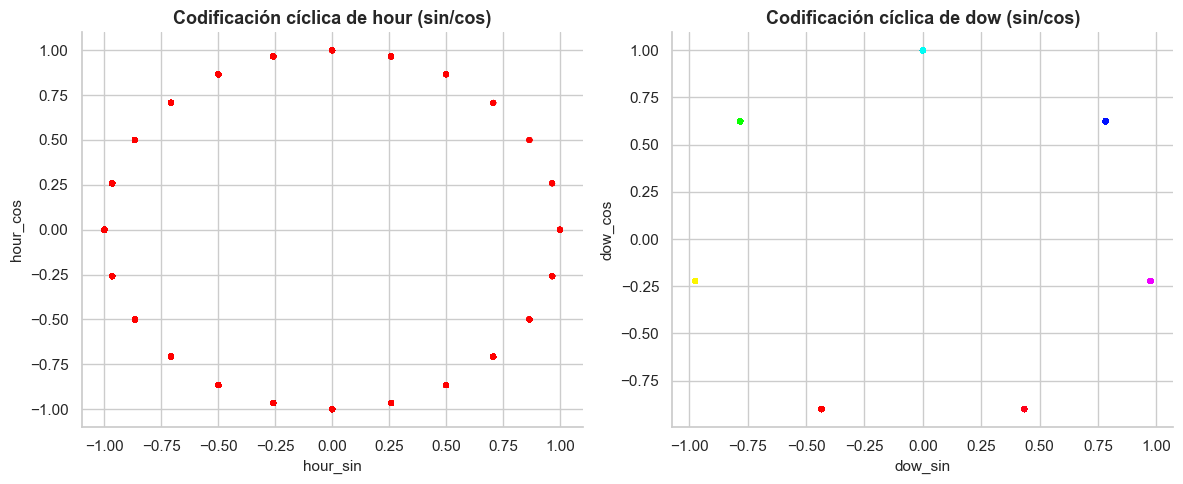

Variables temporales reemplazadas: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [46]:
# Codificación cíclica: hora (período=24) y día de semana (período=7)
for df in [X_train_fe, X_test_fe]:
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']  = np.sin(2 * np.pi * df['dow']  / 7)
    df['dow_cos']  = np.cos(2 * np.pi * df['dow']  / 7)

# Eliminamos las columnas originales (reemplazadas por sin/cos)
X_train_fe = X_train_fe.drop(columns=['hour', 'dow'])
X_test_fe  = X_test_fe.drop(columns=['hour', 'dow'])

# Visualización: circularidad de la hora promedio de propina
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_tmp = X_train_fe.copy()
_tmp['tip'] = y_train.values
_tmp_h = _tmp.groupby(np.round(_tmp['hour_sin'] * 3, 1))['tip'].mean()

scatter_data = _tmp.sample(5000, random_state=42)
sc = axes[0].scatter(
    scatter_data['hour_sin'], scatter_data['hour_cos'],
    c=scatter_data['hour_sin'].map(lambda x: _tmp.loc[scatter_data.index, 'hour_cos'].values[0]),
    cmap='hsv', alpha=0.4, s=10
)
axes[0].set_title('Codificación cíclica de hour (sin/cos)')
axes[0].set_xlabel('hour_sin')
axes[0].set_ylabel('hour_cos')

sc2 = axes[1].scatter(
    scatter_data['dow_sin'], scatter_data['dow_cos'],
    c=np.arctan2(scatter_data['dow_sin'], scatter_data['dow_cos']),
    cmap='hsv', alpha=0.4, s=10
)
axes[1].set_title('Codificación cíclica de dow (sin/cos)')
axes[1].set_xlabel('dow_sin')
axes[1].set_ylabel('dow_cos')

plt.tight_layout()
plt.show()

print("Variables temporales reemplazadas:", ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'])

### 5.3 Codificación de variables categóricas

Cada variable categórica requiere un tratamiento distinto según su cardinalidad y relación con el target:

- **`VendorID`** (2 valores: CMT, Curb) → codificación binaria (drop_first=True, sin colinealidad perfecta)
- **`RatecodeID`** (6 valores nominales: estándar, JFK, Newark, Nassau, negociado, grupal) → one-hot encoding (drop_first=True)
- **`PULocationID` / `DOLocationID`** (~260 zonas cada uno) → **target encoding**: reemplazamos cada zona por la propina promedio en el train. Esta técnica es preferida para alta cardinalidad porque no explota el espacio dimensional y captura directamente la relación zona-propina. Se calcula **solo sobre el train** y se aplica al test para evitar fuga.


In [47]:
# --- VendorID: codificación binaria ---
_vendor_tr = pd.get_dummies(X_train_fe['VendorID'], prefix='vendor', drop_first=True)
_vendor_te = pd.get_dummies(X_test_fe['VendorID'],  prefix='vendor', drop_first=True)

# --- RatecodeID: one-hot encoding ---
_rate_tr = pd.get_dummies(X_train_fe['RatecodeID'], prefix='rate', drop_first=True)
_rate_te = pd.get_dummies(X_test_fe['RatecodeID'],  prefix='rate', drop_first=True)
# Alineamos columnas: el test podría no tener alguna categoría rara
_rate_te = _rate_te.reindex(columns=_rate_tr.columns, fill_value=0)

print("VendorID dummies:", list(_vendor_tr.columns))
print("RatecodeID dummies:", list(_rate_tr.columns))

VendorID dummies: ['vendor_2']
RatecodeID dummies: ['rate_2.0', 'rate_3.0', 'rate_4.0', 'rate_5.0', 'rate_99.0']



Matriz codificada:
  X_train_enc: (2036220, 20)  |  X_test_enc: (509055, 20)
  Columnas: ['trip_distance', 'duration_min', 'fare_amount', 'passenger_count', 'speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'PU_target_enc', 'DO_target_enc', 'vendor_2', 'rate_2.0', 'rate_3.0', 'rate_4.0', 'rate_5.0', 'rate_99.0']


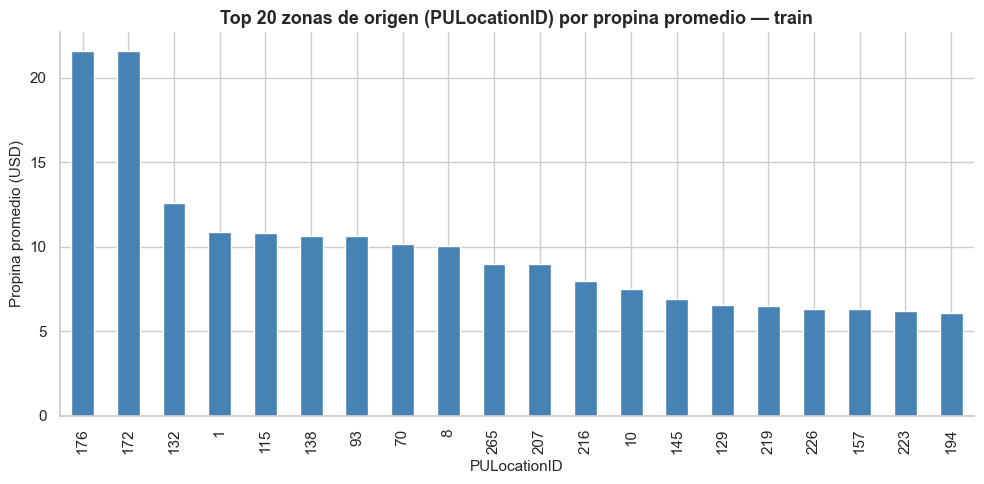

In [48]:
# --- PULocationID / DOLocationID: target encoding (fit solo en train) ---
_y_train_idx = y_train.copy()
_y_train_idx.index = X_train_fe.index  # garantizamos alineación de índices

_pu_means    = _y_train_idx.groupby(X_train_fe['PULocationID']).mean()
_do_means    = _y_train_idx.groupby(X_train_fe['DOLocationID']).mean()
_media_global = _y_train_idx.mean()

X_train_fe['PU_target_enc'] = X_train_fe['PULocationID'].map(_pu_means).fillna(_media_global)
X_test_fe['PU_target_enc']  = X_test_fe['PULocationID'].map(_pu_means).fillna(_media_global)
X_train_fe['DO_target_enc'] = X_train_fe['DOLocationID'].map(_do_means).fillna(_media_global)
X_test_fe['DO_target_enc']  = X_test_fe['DOLocationID'].map(_do_means).fillna(_media_global)

# Eliminamos las columnas categóricas originales (reemplazadas)
_cols_drop = ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']
X_train_fe = X_train_fe.drop(columns=_cols_drop)
X_test_fe  = X_test_fe.drop(columns=_cols_drop)

# Concatenamos los dummies
X_train_enc = pd.concat([X_train_fe, _vendor_tr, _rate_tr], axis=1)
X_test_enc  = pd.concat([X_test_fe,  _vendor_te, _rate_te], axis=1)
X_train_enc.columns = X_train_enc.columns.astype(str)
X_test_enc.columns  = X_test_enc.columns.astype(str)

print("\nMatriz codificada:")
print(f"  X_train_enc: {X_train_enc.shape}  |  X_test_enc: {X_test_enc.shape}")
print(f"  Columnas: {list(X_train_enc.columns)}")

# --- Visualización: top-20 zonas de origen por propina promedio ---
fig, ax = plt.subplots(figsize=(10, 5))
_pu_means.sort_values(ascending=False).head(20).plot.bar(ax=ax, color='steelblue')
ax.set_title('Top 20 zonas de origen (PULocationID) por propina promedio — train')
ax.set_xlabel('PULocationID')
ax.set_ylabel('Propina promedio (USD)')
plt.tight_layout()
plt.show()

### 5.4 Distribución del target y balance de clases

Se trata de un **problema de regresión**, por lo que no aplica el análisis de balance de clases. Sin embargo, la distribución del target (`tip_amount`) es fuertemente asimétrica a la derecha: la mayoría de las propinas son pequeñas y existe una cola larga de propinas altas. Presentamos la distribución original y su versión transformada con `log1p` para ilustrar la asimetría.

> No aplicamos la transformación logarítmica al target en el pipeline definitivo porque queremos preservar la **interpretabilidad en dólares** al evaluar el modelo (RMSE en USD es directamente interpretable).


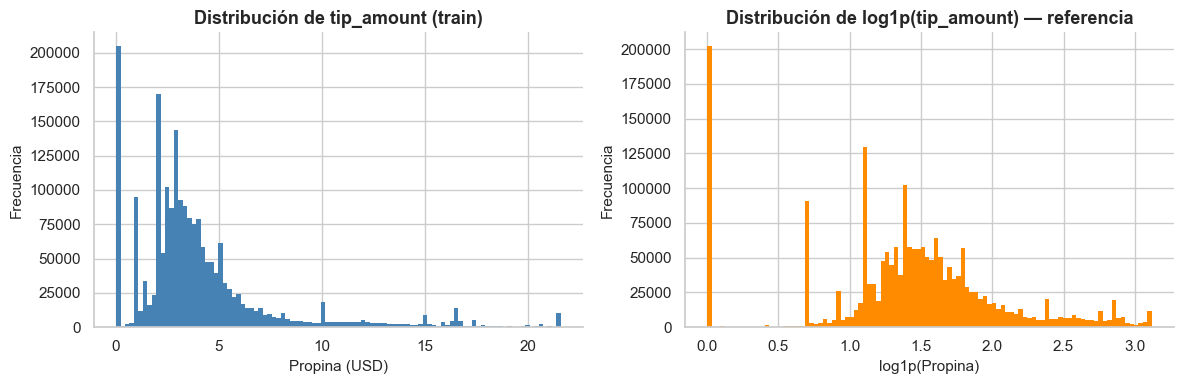

Asimetría (skewness) de tip_amount:        2.19
Asimetría de log1p(tip_amount):            -0.23
Proporción de viajes con propina > 0:      90.2 %


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribución de tip_amount (train)')
axes[0].set_xlabel('Propina (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(y_train), bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Distribución de log1p(tip_amount) — referencia')
axes[1].set_xlabel('log1p(Propina)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Asimetría (skewness) de tip_amount:        {y_train.skew():.2f}")
print(f"Asimetría de log1p(tip_amount):            {np.log1p(y_train).skew():.2f}")
print(f"Proporción de viajes con propina > 0:      {(y_train > 0).mean()*100:.1f} %")

### 5.5 Escalado

Aplicamos `StandardScaler` (Estandarización (Z-score): `X' = (X − μ) / σ`) a las columnas continuas de la nueva matriz. Las dummies (0/1), los indicadores binarios y los senos/cosenos (ya en [-1, 1]) no necesitan escalado adicional.

In [50]:
from sklearn.preprocessing import StandardScaler

_cols_numericas = ['trip_distance', 'duration_min', 'fare_amount', 'passenger_count',
                   'speed_mph', 'fare_per_mile', 'PU_target_enc', 'DO_target_enc']

_scaler_fe = StandardScaler()
X_train_enc_esc = X_train_enc.copy()
X_test_enc_esc  = X_test_enc.copy()

X_train_enc_esc[_cols_numericas] = _scaler_fe.fit_transform(X_train_enc_esc[_cols_numericas])  # fit solo en train
X_test_enc_esc[_cols_numericas]  = _scaler_fe.transform(X_test_enc_esc[_cols_numericas])

print("Matriz final post Feature Engineering + escalado:")
print(f"  X_train_enc_esc: {X_train_enc_esc.shape}   y_train: {y_train.shape}")
print(f"  X_test_enc_esc:  {X_test_enc_esc.shape}    y_test:  {y_test.shape}")
print(f"\nColumnas finales ({X_train_enc_esc.shape[1]}):")
for col in X_train_enc_esc.columns:
    print(f"  - {col}")
X_train_enc_esc.head()

Matriz final post Feature Engineering + escalado:
  X_train_enc_esc: (2036220, 20)   y_train: (2036220,)
  X_test_enc_esc:  (509055, 20)    y_test:  (509055,)

Columnas finales (20):
  - trip_distance
  - duration_min
  - fare_amount
  - passenger_count
  - speed_mph
  - fare_per_mile
  - es_aeropuerto
  - es_hora_pico
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - PU_target_enc
  - DO_target_enc
  - vendor_2
  - rate_2.0
  - rate_3.0
  - rate_4.0
  - rate_5.0
  - rate_99.0


,trip_distance,duration_min,fare_amount,passenger_count,speed_mph,fare_per_mile,es_aeropuerto,es_hora_pico,hour_sin,hour_cos,dow_sin,dow_cos,PU_target_enc,DO_target_enc,vendor_2,rate_2.0,rate_3.0,rate_4.0,rate_5.0,rate_99.0
103344,-0.351151,-0.304923,-0.361554,-0.358714,-0.279656,-0.132057,0,0,0.258819,-9.659258e-01,0.000000,1.000000,-0.140673,1.350022,True,False,False,False,False,False
1924904,-0.147153,-0.262172,-0.188283,1.250421,0.321603,-0.252598,0,0,-0.500000,-8.660254e-01,-0.433884,-0.900969,-0.262744,-0.566853,False,False,False,False,False,False
2809771,-0.209743,0.273331,0.028305,-0.358714,-0.602585,-0.052864,0,1,-1.000000,-1.836970e-16,-0.781831,0.623490,-0.086205,-0.288674,True,False,False,False,False,False
363419,0.038299,0.380207,0.028305,-0.358714,-0.206310,-0.284623,0,0,-0.500000,8.660254e-01,0.974928,-0.222521,-0.215510,-0.145167,False,False,False,False,False,False
1605994,-0.682646,-0.732426,-0.751412,-0.358714,-1.045838,0.631407,0,0,-0.707107,-7.071068e-01,0.781831,0.623490,-0.086205,-0.216725,True,False,False,False,False,False


## 6. Reducción de dimensionalidad (PCA)

Aplicamos **Análisis de Componentes Principales (PCA)** sobre la matriz de entrenamiento ya escalada (`X_train_enc_esc`, 20 features) para:

1. Cuantificar cuánta redundancia hay entre variables (p. ej. distancia, duración, tarifa).
2. Identificar qué ejes ortogonales concentran la mayor varianza.
3. Evaluar si conviene reducir dimensionalidad antes del modelado de `tip_amount`.


In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=X_train_enc_esc.shape[1])
pca.fit(X_train_enc_esc)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X_train_enc_esc.columns
)
loadings.round(3).head(20)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
trip_distance,0.501,-0.093,0.050,-0.078,0.038,0.002,0.086,0.069,0.083,0.087,0.007,-0.038,-0.402,-0.464,-0.492,-0.276,-0.023,0.076,-0.003,-0.000
duration_min,0.402,-0.203,0.369,-0.411,0.067,-0.087,0.046,0.144,-0.072,-0.160,0.010,-0.032,0.488,-0.167,0.378,-0.118,-0.005,0.046,0.028,0.000
fare_amount,0.493,0.064,0.190,-0.080,0.081,-0.024,0.053,0.067,0.024,0.020,-0.007,-0.127,-0.249,0.735,-0.075,0.226,0.037,-0.132,-0.036,-0.000
passenger_count,0.027,0.525,-0.454,-0.702,-0.030,0.077,-0.037,-0.036,0.105,0.027,0.013,0.051,0.007,-0.004,-0.002,-0.001,0.002,-0.002,-0.000,-0.000
speed_mph,0.381,0.005,-0.397,0.361,-0.094,0.151,0.212,0.031,0.418,0.402,-0.032,-0.024,0.295,-0.016,0.249,-0.012,0.004,-0.001,0.011,0.000
fare_per_mile,-0.099,0.697,0.478,0.208,0.324,0.017,0.204,0.152,0.182,0.070,-0.001,-0.005,0.053,-0.128,0.022,-0.067,0.017,-0.007,0.001,0.000
es_aeropuerto,0.057,0.014,-0.004,0.005,0.022,-0.002,-0.011,-0.014,-0.022,-0.004,0.006,-0.021,-0.450,-0.176,0.487,0.213,0.279,0.243,0.089,0.577
es_hora_pico,-0.012,-0.014,0.019,0.002,0.009,-0.011,-0.092,0.022,0.025,0.123,0.986,-0.038,0.011,0.011,0.004,-0.003,0.001,-0.001,-0.000,-0.000
hour_sin,0.010,-0.043,0.091,-0.002,-0.110,0.427,0.318,-0.466,0.360,-0.578,0.105,-0.031,-0.028,0.010,-0.009,-0.008,0.001,-0.000,-0.000,0.000
hour_cos,0.016,0.033,-0.286,0.156,-0.016,-0.389,0.040,0.563,0.258,-0.592,0.061,0.024,-0.029,0.010,-0.012,0.010,0.003,-0.001,-0.001,-0.000


### 6.1 Varianza explicada

El criterio habitual es retener los componentes que acumulan ≥90–95 % de la varianza total. Eso indica cuántas dimensiones ortogonales resumen la estructura de las 20 features originales.


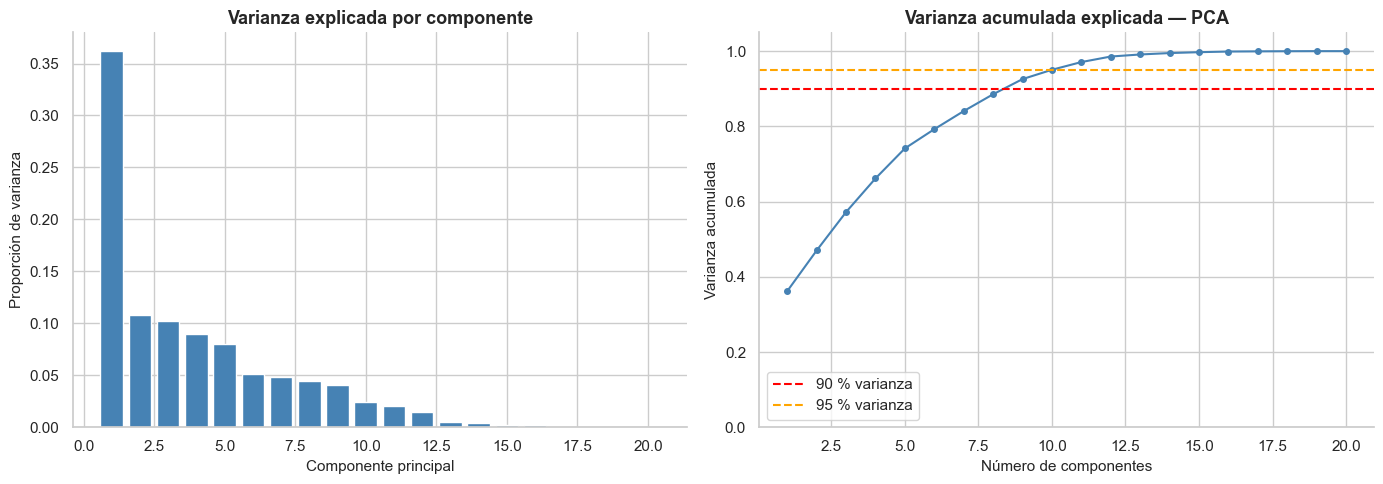

Varianza explicada por los primeros componentes (%):
  PC1: 36.2 %  (acumulada: 36.2 %)
  PC2: 10.8 %  (acumulada: 47.0 %)
  PC3: 10.2 %  (acumulada: 57.2 %)
  PC4: 8.9 %  (acumulada: 66.2 %)
  PC5: 8.0 %  (acumulada: 74.1 %)
  PC6: 5.1 %  (acumulada: 79.2 %)

Componentes para ≥90 % de varianza: 9 (de 20 features originales)
Componentes para ≥95 % de varianza: 10


In [52]:
_varianza = pca.explained_variance_ratio_
_varianza_acum = np.cumsum(_varianza)
_n_comp = len(_varianza_acum)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, _n_comp + 1), _varianza, color='steelblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Proporción de varianza')

axes[1].plot(range(1, _n_comp + 1), _varianza_acum, marker='o', markersize=4, color='steelblue')
axes[1].axhline(0.90, linestyle='--', color='red',    label='90 % varianza')
axes[1].axhline(0.95, linestyle='--', color='orange', label='95 % varianza')
axes[1].set_title('Varianza acumulada explicada — PCA')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

_n_90 = int(np.argmax(_varianza_acum >= 0.90) + 1)
_n_95 = int(np.argmax(_varianza_acum >= 0.95) + 1)

print('Varianza explicada por los primeros componentes (%):')
for i in range(min(6, _n_comp)):
    print(f'  PC{i+1}: {_varianza[i]*100:.1f} %  (acumulada: {_varianza_acum[i]*100:.1f} %)')
print(f'\nComponentes para ≥90 % de varianza: {_n_90} (de {_n_comp} features originales)')
print(f'Componentes para ≥95 % de varianza: {_n_95}')

### 6.2 Loadings — interpretación de los componentes

Los **loadings** indican la correlación de cada variable original con cada componente. Un heatmap resume qué features dominan cada PC.


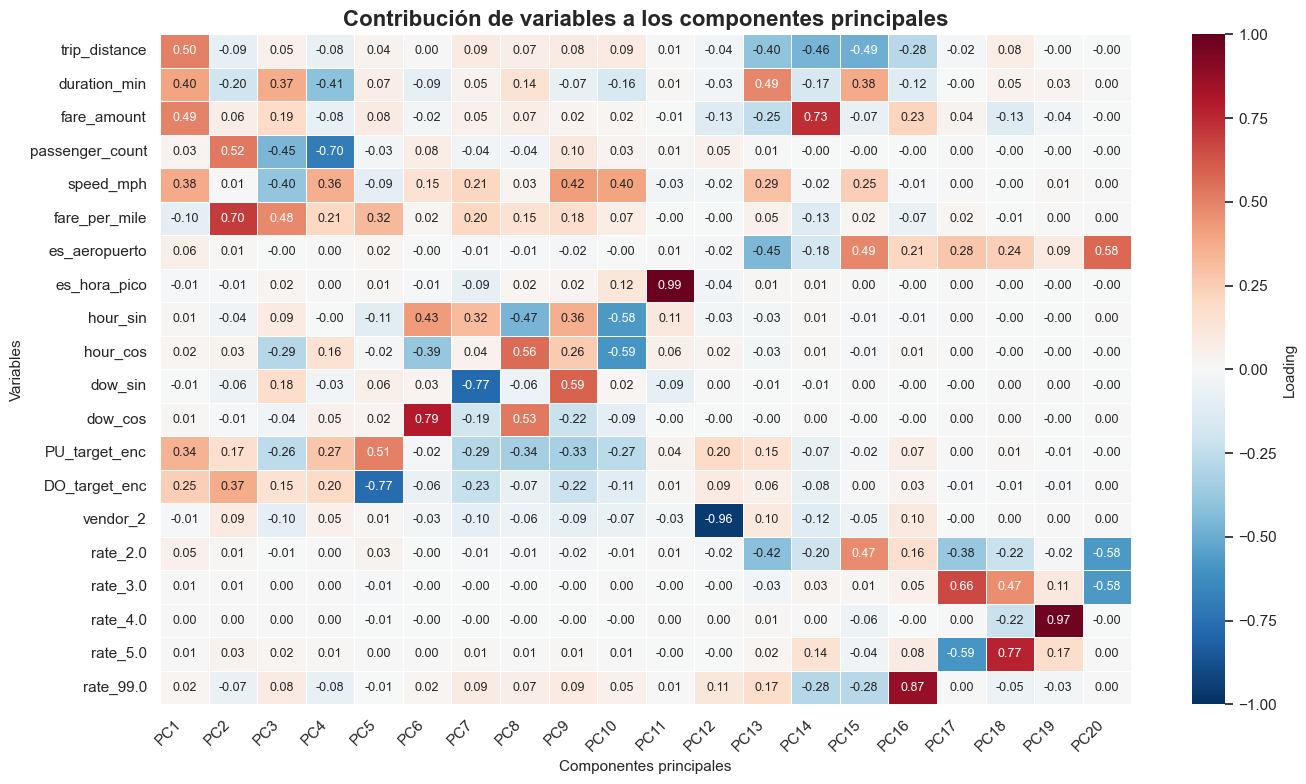

In [53]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Loading'},
    annot_kws={'size': 9}
)

plt.title('Contribución de variables a los componentes principales', fontsize=16)
plt.xlabel('Componentes principales')
plt.ylabel('Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.3 Interpretación de los primeros componentes

| PC | Varianza | Interpretación (según top loadings) |
|---|---|---|
| **PC1** (36,2 %) | **Escala del viaje** | `trip_distance`, `fare_amount`, `duration_min` y `speed_mph` dominan. El bloque distancia-tarifa-duración —altamente correlacionado— concentra la mayor porción de varianza; es el resultado esperado una vez que todas las features están en la misma escala. |
| **PC2** (10,8 %) | **Tarifa + destino** | `fare_per_mile` y `passenger_count` lideran, acompañados de `DO_target_enc` y `duration_min`. Mezcla estructura tarifaria con características del destino. |
| **PC3** (10,2 %) | **Tarifa / velocidad** | `fare_per_mile`, `passenger_count`, `speed_mph` y `duration_min`. Contraste entre tarifas planas (aeropuerto, negociadas) y tarifas variables; combinación lineal ortogonal a PC2. |
| **PC4** (8,9 %) | **Origen geográfico** | `passenger_count`, `duration_min`, `speed_mph` y `PU_target_enc`. La zona de origen emerge aquí, más tarde que en el PCA sin escalar. |
| **PC5** (8,0 %) | **Geografía OD** | `DO_target_enc`, `PU_target_enc`, `fare_per_mile` y `hour_sin`. Contraste entre zonas de origen y destino en propensión a propina, con componente horaria. |
| **PC6** (5,1 %) | **Temporalidad** | `dow_cos`, `hour_sin`, `hour_cos` y `speed_mph`. Patrones cíclicos de hora y día de semana. |

**Lectura conjunta:** con el escalado correcto, los primeros 3 PCs (≈57 % varianza) revelan la estructura esperada: **escala del viaje** (PC1) seguida de **estructura tarifaria** (PC2–PC3). La **geografía** (zonas TLC) recién emerge en **PC4–PC5**, con ≈17 % de varianza combinada. Se necesitan **9 PCs** para alcanzar el 90 % de varianza.


In [54]:
print('Resumen de componentes principales (train):\n')
for i in range(min(6, pca.n_components_)):
    pc = f'PC{i+1}'
    top_vars = loadings[pc].abs().nlargest(4).index.tolist()
    print(f"  {pc}: {_varianza[i]*100:5.1f} % varianza  |  top loadings: {', '.join(top_vars)}")
print(f'\n→ {_n_90} PCs alcanzan ≥90 % varianza; {_n_95} PCs alcanzan ≥95 %.')

Resumen de componentes principales (train):

  PC1:  36.2 % varianza  |  top loadings: trip_distance, fare_amount, duration_min, speed_mph
  PC2:  10.8 % varianza  |  top loadings: fare_per_mile, passenger_count, DO_target_enc, duration_min
  PC3:  10.2 % varianza  |  top loadings: fare_per_mile, passenger_count, speed_mph, duration_min
  PC4:   8.9 % varianza  |  top loadings: passenger_count, duration_min, speed_mph, PU_target_enc
  PC5:   8.0 % varianza  |  top loadings: DO_target_enc, PU_target_enc, fare_per_mile, hour_sin
  PC6:   5.1 % varianza  |  top loadings: dow_cos, hour_sin, hour_cos, speed_mph

→ 9 PCs alcanzan ≥90 % varianza; 10 PCs alcanzan ≥95 %.


### 6.4 Scores y biplot (PC1 vs PC2)

Proyectamos una **muestra aleatoria del train** (10 000 filas) sobre los dos primeros componentes. El biplot superpone los vectores de loadings para ver qué variables empujan cada observación.


In [55]:
_rng = np.random.default_rng(42)
_sample_idx = _rng.choice(len(X_train_enc_esc), size=10_000, replace=False)
_scores = pca.transform(X_train_enc_esc.iloc[_sample_idx])
scores = pd.DataFrame(
    _scores,
    columns=[f'PC{i+1}' for i in range(_scores.shape[1])]
)
scores[['PC1', 'PC2']].describe().round(2)

,PC1,PC2
count,10000.00,10000.00
mean,0.02,-0.02
std,1.96,0.93
min,-2.25,-2.92
25%,-1.13,-0.37
50%,-0.73,-0.18
75%,0.15,0.19
max,8.97,21.46


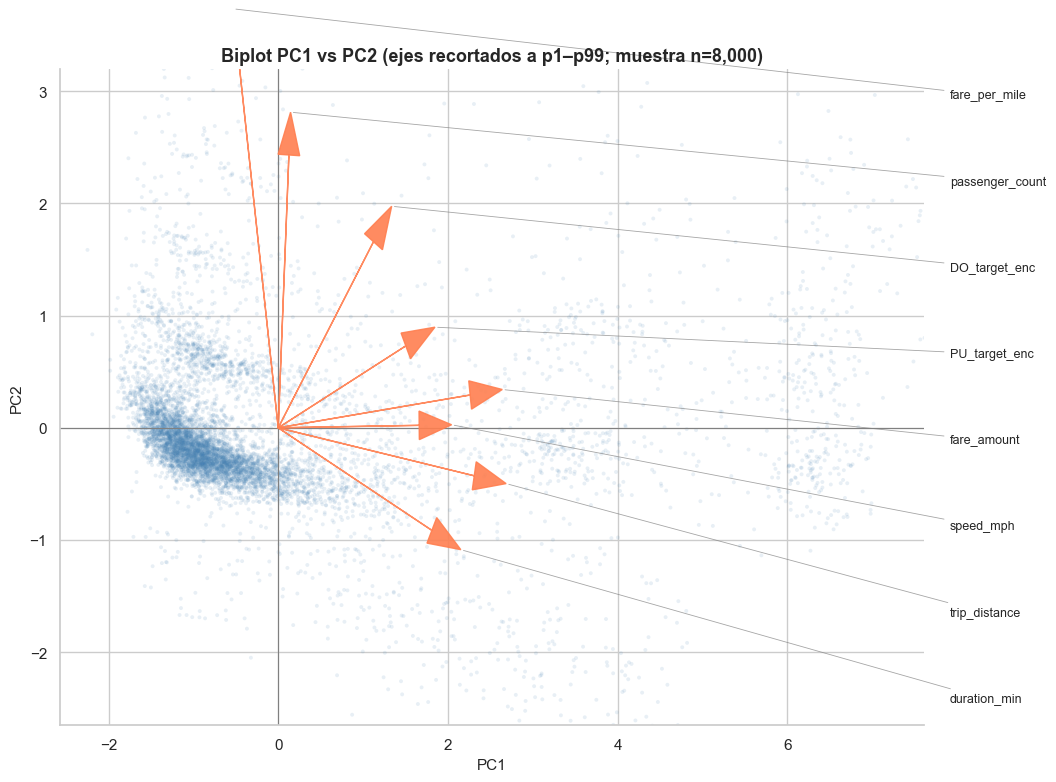

In [56]:
def plot_biplot(scores, loadings, pcx='PC1', pcy='PC2', top_n=8, sample=8000):
    s = scores.sample(min(sample, len(scores)), random_state=0)
    xlo, xhi = scores[pcx].quantile([.01, .99])
    ylo, yhi = scores[pcy].quantile([.01, .99])
    dx, dy = xhi - xlo, yhi - ylo
    xlim = (xlo - 0.10 * dx, xhi + 0.10 * dx)
    ylim = (ylo - 0.12 * dy, yhi + 0.12 * dy)

    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(left=0.08, right=0.80, top=0.92, bottom=0.10)  # lugar a la derecha p/etiquetas
    ax.scatter(s[pcx], s[pcy], alpha=0.12, s=8, color='steelblue', edgecolors='none')

    # Variables más influyentes en este plano (PC1, PC2)
    importance = loadings[pcx] ** 2 + loadings[pcy] ** 2
    selected = importance.nlargest(top_n).index.tolist()

    # Escala UNIFORME de flechas (preserva ángulos) para que llenen el área visible
    scale = 0.80 * min(dx, dy) / np.sqrt(importance[selected]).max()

    # Etiquetas en una columna FUERA del área de datos (coords de eje), repartidas
    # uniformemente y ordenadas por la y de su flecha -> nunca se pisan ni se cortan.
    selected = sorted(selected, key=lambda f: loadings.loc[f, pcy])   # de abajo hacia arriba
    fracs = np.linspace(0.04, 0.96, len(selected))
    for frac, feat in zip(fracs, selected):
        x, y = loadings.loc[feat, pcx] * scale, loadings.loc[feat, pcy] * scale
        ax.arrow(0, 0, x, y, color='coral', alpha=0.9,
                 head_width=0.03 * dx, length_includes_head=True, zorder=3)
        ax.annotate(feat, xy=(x, y), xycoords='data',
                    xytext=(1.03, frac), textcoords='axes fraction',
                    fontsize=9, va='center', ha='left', annotation_clip=False,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.7))

    ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel(pcx); ax.set_ylabel(pcy)
    ax.set_title(f'Biplot {pcx} vs {pcy} (ejes recortados a p1–p99; muestra n={len(s):,})')
    plt.show()

plot_biplot(scores, loadings, 'PC1', 'PC2')

### 6.5 Conclusión

Con las 20 variables escaladas, se necesitan aproximadamente **9 componentes principales para capturar el 90% de la varianza** y **10 componentes para alcanzar el 95%**. Esto indica que la información está distribuida entre muchas dimensiones y que **no es posible reducir el dataset a unas pocas componentes sin perder una parte importante de la señal**. En la práctica, la reducción solo permite pasar de 20 variables a unas 9 o 10, es decir, aproximadamente a la mitad.

Además, **PCA es un método ciego al target**. Su objetivo es conservar la mayor cantidad posible de varianza en las variables de entrada (*X*), pero **desconoce que el problema consiste en predecir la propina (`tip_amount`)**. Como consecuencia, variables que podrían ser predictoras importantes pueden quedar relegadas a componentes tardías simplemente porque aportan poca varianza global al dataset.

Por ejemplo, variables como `es_aeropuerto` o `es_hora_pico` pueden aparecer poco frecuentemente y, por lo tanto, tener un peso reducido en las primeras componentes. Sin embargo, esas mismas variables podrían estar asociadas a patrones relevantes de propina. Un viaje al aeropuerto representa una fracción pequeña de los viajes totales, pero puede tener un comportamiento de propinas muy distinto al promedio.

Por estas razones, **no se recomienda utilizar PCA como preprocesamiento para el modelo de predicción de propinas**. Aunque resulta útil para exploración y análisis de datos, también mezcla distintas fuentes de información en componentes difíciles de interpretar y puede ocultar señales predictivas importantes. Para este caso, es preferible trabajar con las **20 variables originales**, preservando toda la información disponible y manteniendo una interpretación más clara de los resultados.


## 7. Resumen train/test — dataset listo para modelado

Tras el preprocesamiento (§4), ingeniería de features (§5) y el análisis exploratorio con PCA (§6), el pipeline deja **dos conjuntos alineados** listos para entrenar un regresor **sin haber elegido ni ajustado ningún modelo todavía**.

### 7.1 Universo y partición

| Etapa | Detalle |
|---|---|
| Dataset crudo | 3.952.451 viajes (marzo 2026) |
| Filtro tarjeta + limpieza | 2.545.275 viajes válidos |
| **Split** | **80 % train / 20 % test** (`random_state=42`) |
| **Train** | **2.036.220** filas |
| **Test** | **509.055** filas |

El split se hizo **antes** de winsorizar, codificar y escalar → los límites y estadísticos del train no filtran información al test.

### 7.2 Objetos finales para el modelado

| Variable | Train | Test | Descripción |
|---|---:|---:|---|
| **`X_train_enc_esc`** / **`X_test_enc_esc`** | (2.036.220, 20) | (509.055, 20) | Matriz de features codificada y escalada |
| **`y_train`** / **`y_test`** | (2.036.220,) | (509.055,) | Target `tip_amount` (USD), cap superior p99,5 del train |

### 7.3 Transformaciones aplicadas (fit en train → apply en test)

1. **Winsorización de features** (`trip_distance`, `duration_min`, `fare_amount`): límites p1–p99 del train.
2. **Target cap**: `tip_amount` recortado a **[0, 21,61] USD** (p99,5 del train).
3. **Feature engineering**: `speed_mph`, `fare_per_mile`, `es_aeropuerto`, `es_hora_pico`, codificación cíclica hora/día.
4. **Encoding**: dummies de `VendorID`/`RatecodeID`; **target encoding** de zonas TLC (`PU_target_enc`, `DO_target_enc`).
5. **Escalado**: `StandardScaler` en 8 columnas numéricas continuas; dummies e indicadores sin escalar.
6. **PCA (§6)**: solo diagnóstico → **no se usa** como input del modelo; se mantienen las 20 features originales.


In [57]:
# --- Resumen final: train vs test listo para modelado ---

_particion = pd.DataFrame({
    'Conjunto': ['Train', 'Test', 'Total'],
    'Filas': [
        len(X_train_enc_esc),
        len(X_test_enc_esc),
        len(X_train_enc_esc) + len(X_test_enc_esc),
    ],
    'Features': [X_train_enc_esc.shape[1]] * 3,
    'Target': ['tip_amount (USD)'] * 3,
})
display(_particion.set_index('Conjunto'))

print('\n--- Target: y_train / y_test (post-cap p99.5 train) ---')
display(
    pd.concat([y_train.describe(), y_test.describe()], axis=1)
    .round(2)
    .rename(columns={0: 'y_train', 1: 'y_test'})
)
print(f"Propina > 0  →  train: {(y_train > 0).mean()*100:.1f} %  |  test: {(y_test > 0).mean()*100:.1f} %")

print(f'\n--- Features finales ({X_train_enc_esc.shape[1]} columnas) ---')
for i, col in enumerate(X_train_enc_esc.columns, 1):
    print(f'  {i:2d}. {col}')

print('\n--- Chequeos de integridad ---')
_checks = {
    'Misma cantidad de filas X ↔ y (train)': len(X_train_enc_esc) == len(y_train),
    'Misma cantidad de filas X ↔ y (test)':  len(X_test_enc_esc)  == len(y_test),
    'Mismas columnas train/test':            X_train_enc_esc.columns.equals(X_test_enc_esc.columns),
    'Sin NaN en X_train':                  X_train_enc_esc.isna().sum().sum() == 0,
    'Sin NaN en X_test':                   X_test_enc_esc.isna().sum().sum()  == 0,
    'Sin NaN en y_train':                  y_train.isna().sum() == 0,
    'Sin NaN en y_test':                   y_test.isna().sum()  == 0,
}
for k, v in _checks.items():
    print(f'  [{"OK" if v else "FAIL"}] {k}')

print('\n→ Próximo paso: elegir regresor, entrenar con (X_train_enc_esc, y_train) y evaluar en (X_test_enc_esc, y_test).')

,Filas,Features,Target
Conjunto,,,
Train,2036220,20,tip_amount (USD)
Test,509055,20,tip_amount (USD)
Total,2545275,20,tip_amount (USD)



--- Target: y_train / y_test (post-cap p99.5 train) ---


,tip_amount,tip_amount
count,2036220.00,509055.00
mean,4.10,4.11
std,3.75,3.76
min,0.00,0.00
25%,2.00,2.00
50%,3.20,3.21
75%,4.83,4.83
max,21.61,21.61


Propina > 0  →  train: 90.2 %  |  test: 90.2 %

--- Features finales (20 columnas) ---
   1. trip_distance
   2. duration_min
   3. fare_amount
   4. passenger_count
   5. speed_mph
   6. fare_per_mile
   7. es_aeropuerto
   8. es_hora_pico
   9. hour_sin
  10. hour_cos
  11. dow_sin
  12. dow_cos
  13. PU_target_enc
  14. DO_target_enc
  15. vendor_2
  16. rate_2.0
  17. rate_3.0
  18. rate_4.0
  19. rate_5.0
  20. rate_99.0

--- Chequeos de integridad ---
  [OK] Misma cantidad de filas X ↔ y (train)
  [OK] Misma cantidad de filas X ↔ y (test)
  [OK] Mismas columnas train/test
  [OK] Sin NaN en X_train
  [OK] Sin NaN en X_test
  [OK] Sin NaN en y_train
  [OK] Sin NaN en y_test

→ Próximo paso: elegir regresor, entrenar con (X_train_enc_esc, y_train) y evaluar en (X_test_enc_esc, y_test).


## 8. Conclusiones

Síntesis de lo aprendido en el análisis exploratorio, el preprocesamiento y el PCA. **Este notebook no entrena ni evalúa modelos**; las afirmaciones sobre qué variables “explican” mejor la propina provienen del EDA, del dominio del negocio y del PCA sobre *X*, no de un ranking de importancia sobre *y*.

### 8.1 Problema y target

- Planteamos **regresión de `tip_amount` (USD)** sobre viajes de **marzo 2026** del yellow cab de NYC.
- Tras filtrar a **pagos con tarjeta** y limpiar inconsistencias, el universo de modelado queda en **2.545.275 viajes** (64,4 % del dataset original). En ese subconjunto, el **90,2 %** deja propina > 0; la mediana es **3,20 USD** (media 4,14 USD).
- Restringir el análisis a **tarjeta fue una decisión metodológica correcta**, no una limitación: la propina en efectivo **no se registra** (MNAR según el diccionario TLC). Incluir efectivo habría mezclado “medio de pago” con “comportamiento de propina”.

### 8.2 Calidad y preprocesamiento

- El dataset crudo tiene **colas extremas y errores imposibles** (distancias de cientos de miles de millas, duraciones ≤ 0, importes negativos, fechas fuera de marzo 2026). Por eso priorizamos **estadística robusta** (mediana, IQR, MAD, Spearman/Kendall) y distinguimos **errores a eliminar** de **outliers plausibles a acotar**.
- El pipeline evita **data-leakage**: split **80/20** **antes** de winsorizar, codificar y escalar; todos los estadísticos se calculan **solo en train** y se aplican al test.
- Winsorizamos features con **p1–p99 del train** (no IQR×1,5, para no borrar viajes largos legítimos como aeropuerto). El target se capa en **p99,5 del train** (21,61 USD).
- Excluimos `total_amount` como predictor porque **incluye la propina** → fuga de información directa.

### 8.3 Variables candidatas (sin modelado aún) (sin modelado aún)

- **Argumento de dominio:** las sugerencias de propina en la terminal de pago suelen ser **porcentajes de la tarifa**, no del tiempo. Esto hace plausible que `fare_amount` y `fare_per_mile` sean predictores fuertes —pero **aún no lo cuantificamos** con correlaciones impresas ni con un modelo.
- **Geografía (zonas TLC):** el negocio es **Manhattan-céntrico** (~86 % de orígenes/destinos) y el target encoding muestra **propinas promedios muy distintas por zona**. Las zonas actúan como **proxy** de tipo de viaje y perfil de pasajero no observado directamente.
- **Temporalidad:** hay patrones horarios visibles (p. ej. propina promedio más baja en horas laborales matutinas vs nocturnas), pero en el PCA ocupan **PC5–PC6** con poca varianza individual. Son candidatas a features, no necesariamente los predictores dominantes.
- **Multicolinealidad:** distancia, duración y tarifa están fuertemente asociadas (Spearman 0,79–0,85 en el EDA), y en el PCA la **escala del viaje domina el primer eje** (PC1, 36,2 %) —como se espera una vez que todas las features están correctamente escaladas—. La geografía emerge en PC4–PC5.

### 8.4 PCA y dimensionalidad

- Con **20 features escaladas** (`StandardScaler`), **9 PCs** alcanzan ≥**90 %** de varianza de *X* y **10 PCs** ≥**95 %**.
- **PC1 (36,2 %)** está dominado por `trip_distance`, `fare_amount`, `duration_min` y `speed_mph` (escala del viaje); la geografía (`PU_target_enc`, `DO_target_enc`) aparece en **PC4–PC5**; la estructura tarifaria (`fare_per_mile`) se distribuye en **PC2–PC3**.
- **No recomendamos PCA como preprocesamiento** para modelar propina: mezcla señal geográfica con tarifaria, pierde interpretabilidad y la varianza explicada de *X* no garantiza poder predictivo sobre *y*. Mantenemos las **20 features originales** post-encoding.

### 8.5 Límites y próximos pasos

- El dataset **no registra** clima, eventos, calidad del servicio ni estado de ánimo del pasajero. Parte de la varianza de la propina será **irreducible** con estas variables; eso solo se puede cuantificar entrenando un modelo y midiendo error residual.
- Como se resume en **§7**, el pipeline deja **`X_train_enc_esc` / `X_test_enc_esc`** y **`y_train` / `y_test`** listos para modelar. Falta el paso central del TP: **entrenar, validar y comparar modelos** (p. ej. Ridge, Random Forest, XGBoost) con métricas como MAE/RMSE en test.
- Como extensión, convendría reportar **correlaciones robustas de cada feature con `tip_amount`**, evaluar **suavizado en target encoding** para zonas raras, y comparar si un modelo con las 20 features supera a uno sin las variables redundantes (`fare_per_mile`, etc.).
